In [1]:
import pandas as pd

df = pd.read_csv("METABRIC_RNA_Mutation.csv", low_memory=False)
df_luma = df[df["pam50_+_claudin-low_subtype"] == "LumA"].copy()

print(f"LumA patients: {len(df_luma)}")

LumA patients: 679


In [2]:
#seperate categories
clinical_cols = [
    "tumor_size",
    "tumor_stage",
    "neoplasm_histologic_grade",
    "lymph_nodes_examined_positive",
    "nottingham_prognostic_index",
    "cohort",
    "cellularity",
    "er_status",
    "her2_status",
    "pr_status",
    "tumor_other_histologic_subtype",
    "inferred_menopausal_state",
]

gene_cols = df_luma.columns[31:520].tolist()

mutation_cols = [c for c in df_luma.columns if c.endswith("_mut")]

print(f"Clinical:  {len(clinical_cols)}")
print(f"Genes:     {len(gene_cols)}")
print(f"Mutations: {len(mutation_cols)}")

Clinical:  12
Genes:     489
Mutations: 173


In [3]:
#encoding clinical categoris
# Binary (Positive/Negative → 1/0)
for col in ["er_status", "her2_status", "pr_status"]:
    df_luma[col] = (df_luma[col] == "Positive").astype(int)

# Menopause (Post/Pre → 1/0)
df_luma["inferred_menopausal_state"] = (
    df_luma["inferred_menopausal_state"] == "Post"
).astype(int)

# Cellularity (ordinal: Low < Moderate < High)
cell_map = {"Low": 0, "Moderate": 1, "High": 2}
df_luma["cellularity"] = df_luma["cellularity"].map(cell_map)

# Histologic subtype (one-hot — δεν είναι ordinal)
df_luma = pd.get_dummies(
    df_luma,
    columns=["tumor_other_histologic_subtype"],
    prefix="hist",
    dummy_na=False,
)

# Update clinical_cols (τα one-hot έχουν νέα ονόματα)
hist_cols = [c for c in df_luma.columns if c.startswith("hist_")]
clinical_cols = [
    "tumor_size", "tumor_stage", "neoplasm_histologic_grade",
    "lymph_nodes_examined_positive", "nottingham_prognostic_index",
     "cohort", "cellularity",
    "er_status", "her2_status", "pr_status",
    "inferred_menopausal_state",
] + hist_cols

print(f"Clinical (after encoding): {len(clinical_cols)}")

Clinical (after encoding): 17


In [4]:
#encoding mutations
for col in mutation_cols:
    df_luma[col] = df_luma[col].apply(
        lambda x: 0 if pd.isna(x) or str(x).strip() == "0" else 1
    )

print(f"Mutations binarized: {len(mutation_cols)}")

Mutations binarized: 173


In [5]:
#treatment way
df_luma["mastectomy"] = (
    df_luma["type_of_breast_surgery"] == "MASTECTOMY"
).astype(int)

treatment_cols = [
    "chemotherapy",
    "hormone_therapy",
    "radio_therapy",
    "mastectomy",
]

print(f"Treatment: {len(treatment_cols)}")
df_luma = df_luma.copy()

Treatment: 4


C:\Users\theod\AppData\Local\Temp\ipykernel_12536\4254901131.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_luma["mastectomy"] = (


In [6]:
missing = df_luma[clinical_cols].isna().sum()
missing_pct = (missing / len(df_luma) * 100).round(1)

missing_df = pd.DataFrame({
    "missing": missing,
    "percent": missing_pct,
}).sort_values("missing", ascending=False)

print(missing_df[missing_df["missing"] > 0])

                           missing  percent
tumor_stage                    159     23.4
neoplasm_histologic_grade       31      4.6
cellularity                      7      1.0
tumor_size                       1      0.1


In [7]:
#how to cover missing values in neoplasm_histologic_grade 
df_luma["target"] = df_luma["death_from_cancer"].apply(
    lambda x: 1 if str(x).strip().lower() == "died of disease" else 0
)

profiles = df_luma.groupby("neoplasm_histologic_grade")[
    ["tumor_size", "lymph_nodes_examined_positive",
     "nottingham_prognostic_index", "mutation_count",
     "er_status", "her2_status", "pr_status", "target"]
].mean().round(2)

print(profiles)
print(f"\nCounts per grade:")
print(df_luma["neoplasm_histologic_grade"].value_counts().sort_index())

#we fill the missing values
def impute_grade_from_npi(row):
    if not pd.isna(row["neoplasm_histologic_grade"]):
        return row["neoplasm_histologic_grade"]
    npi = row["nottingham_prognostic_index"]
    if pd.isna(npi):
        return 2.0  # fallback: median
    if npi < 3.0:
        return 1.0
    if npi < 4.2:
        return 2.0
    return 3.0

n_missing_before = df_luma["neoplasm_histologic_grade"].isna().sum()
df_luma["neoplasm_histologic_grade"] = df_luma.apply(impute_grade_from_npi, axis=1)
n_missing_after = df_luma["neoplasm_histologic_grade"].isna().sum()

print(f"Grade missing: {n_missing_before} → {n_missing_after}")
print(f"\nNew distribution:")
print(df_luma["neoplasm_histologic_grade"].value_counts().sort_index())

                           tumor_size  lymph_nodes_examined_positive  \
neoplasm_histologic_grade                                              
1.0                             21.24                           0.85   
2.0                             23.32                           1.26   
3.0                             26.77                           2.43   

                           nottingham_prognostic_index  mutation_count  \
neoplasm_histologic_grade                                                
1.0                                               2.44            5.02   
2.0                                               3.58            5.55   
3.0                                               4.76            5.95   

                           er_status  her2_status  pr_status  target  
neoplasm_histologic_grade                                             
1.0                             1.00         0.01       0.85    0.10  
2.0                             0.99         0.02      

In [8]:
#how to cover missing values in tumor stage
stage_profile = df_luma.groupby("tumor_stage")[
    ["tumor_size", "lymph_nodes_examined_positive",
     "nottingham_prognostic_index", "neoplasm_histologic_grade", "target"]
].mean().round(2)

print(stage_profile)
print(f"\nCounts per stage:")
print(df_luma["tumor_stage"].value_counts().sort_index())

#we fill the missing values
def impute_stage(row):
    if not pd.isna(row["tumor_stage"]):
        return row["tumor_stage"]
    size = row["tumor_size"]
    ln = row["lymph_nodes_examined_positive"]
    if pd.isna(size) or pd.isna(ln):
        return 2.0  # fallback
    # TNM rules
    if size > 50 or ln >= 4:
        return 3.0
    if size <= 20 and ln == 0:
        return 1.0
    return 2.0

n_before = df_luma["tumor_stage"].isna().sum()
df_luma["tumor_stage"] = df_luma.apply(impute_stage, axis=1)
n_after = df_luma["tumor_stage"].isna().sum()

print(f"Stage missing: {n_before} → {n_after}")
print(f"\nNew distribution:")
print(df_luma["tumor_stage"].value_counts().sort_index())

             tumor_size  lymph_nodes_examined_positive  \
tumor_stage                                              
1.0               16.68                           0.01   
2.0               26.79                           2.01   
3.0               49.77                           6.15   
4.0               23.50                           3.50   

             nottingham_prognostic_index  neoplasm_histologic_grade  target  
tumor_stage                                                                  
1.0                                 2.96                       1.94    0.17  
2.0                                 4.01                       2.18    0.25  
3.0                                 4.68                       2.12    0.42  
4.0                                 4.05                       2.00    1.00  

Counts per stage:
tumor_stage
1.0    211
2.0    281
3.0     26
4.0      2
Name: count, dtype: int64
Stage missing: 159 → 0

New distribution:
tumor_stage
1.0    248
2.0    375
3.0   

In [9]:
##how to cover missing values in cellularity
cell_wide = df_luma.groupby("cellularity")[
    ["tumor_size", "lymph_nodes_examined_positive",
     "neoplasm_histologic_grade", "nottingham_prognostic_index",
     "er_status", "her2_status", "pr_status",
     "inferred_menopausal_state", "target"]
].mean().round(2)

print(cell_wide)

##we fill the missing values(with median, becasuse no pattern found)
median_cell = df_luma["cellularity"].median()
print(f"Median cellularity: {median_cell}")
df_luma["cellularity"] = df_luma["cellularity"].fillna(
    df_luma["cellularity"].median()
)
print(f"Missing: {df_luma['cellularity'].isna().sum()}")

             tumor_size  lymph_nodes_examined_positive  \
cellularity                                              
0.0               22.62                           1.20   
1.0               23.47                           1.47   
2.0               24.39                           1.59   

             neoplasm_histologic_grade  nottingham_prognostic_index  \
cellularity                                                           
0.0                               1.78                         3.22   
1.0                               2.07                         3.58   
2.0                               2.06                         3.69   

             er_status  her2_status  pr_status  inferred_menopausal_state  \
cellularity                                                                 
0.0               1.00         0.04       0.80                       0.75   
1.0               1.00         0.04       0.77                       0.82   
2.0               0.99         0.03       0.7

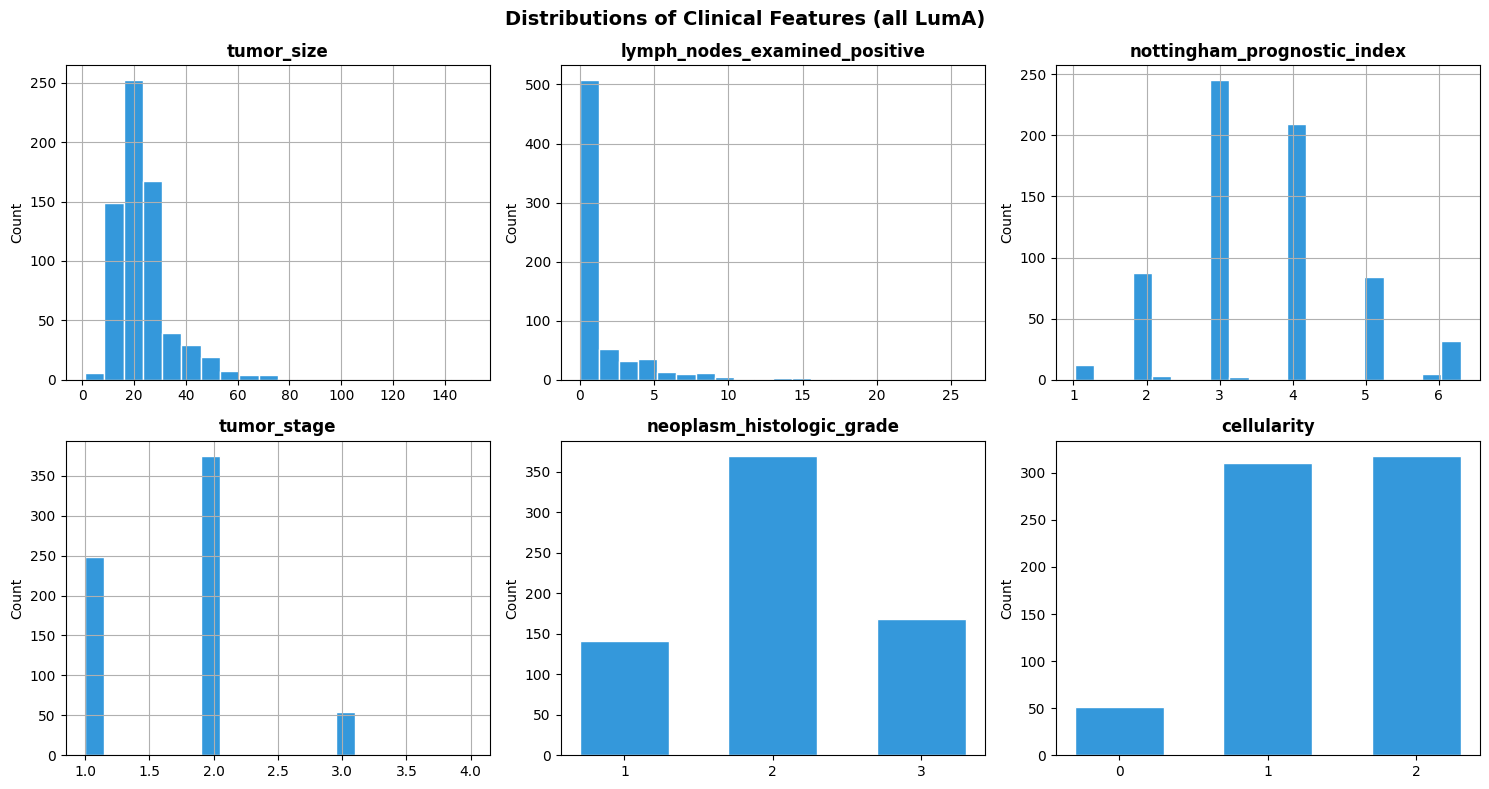

In [10]:
#EDA
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Συνεχή: histograms
for ax, col in zip(
    [axes[0,0], axes[0,1], axes[0,2], axes[1,0]],
    ["tumor_size", "lymph_nodes_examined_positive",
     "nottingham_prognostic_index", "tumor_stage"],
):
    df_luma[col].hist(ax=ax, bins=20, color="#3498DB", edgecolor="white")
    ax.set_title(col, fontweight="bold")
    ax.set_ylabel("Count")

# Διακριτά: bar charts
for ax, col in zip(
    [axes[1,1], axes[1,2]],
    ["neoplasm_histologic_grade", "cellularity"],
):
    counts = df_luma[col].value_counts().sort_index()
    ax.bar(counts.index.astype(int), counts.values,
           color="#3498DB", edgecolor="white", width=0.6)
    ax.set_xticks(counts.index.astype(int))
    ax.set_title(col, fontweight="bold")
    ax.set_ylabel("Count")

plt.suptitle("Distributions of Clinical Features (all LumA)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

C:\Users\theod\AppData\Local\Temp\ipykernel_12536\2733115191.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=["Lived", "Died"], patch_artist=True,
C:\Users\theod\AppData\Local\Temp\ipykernel_12536\2733115191.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=["Lived", "Died"], patch_artist=True,
C:\Users\theod\AppData\Local\Temp\ipykernel_12536\2733115191.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=["Lived", "Died"], patch_artist=True,
C:\Users\theod\AppData\Local\Temp\ipykernel_12536\2733115191.py:19: MatplotlibDepr

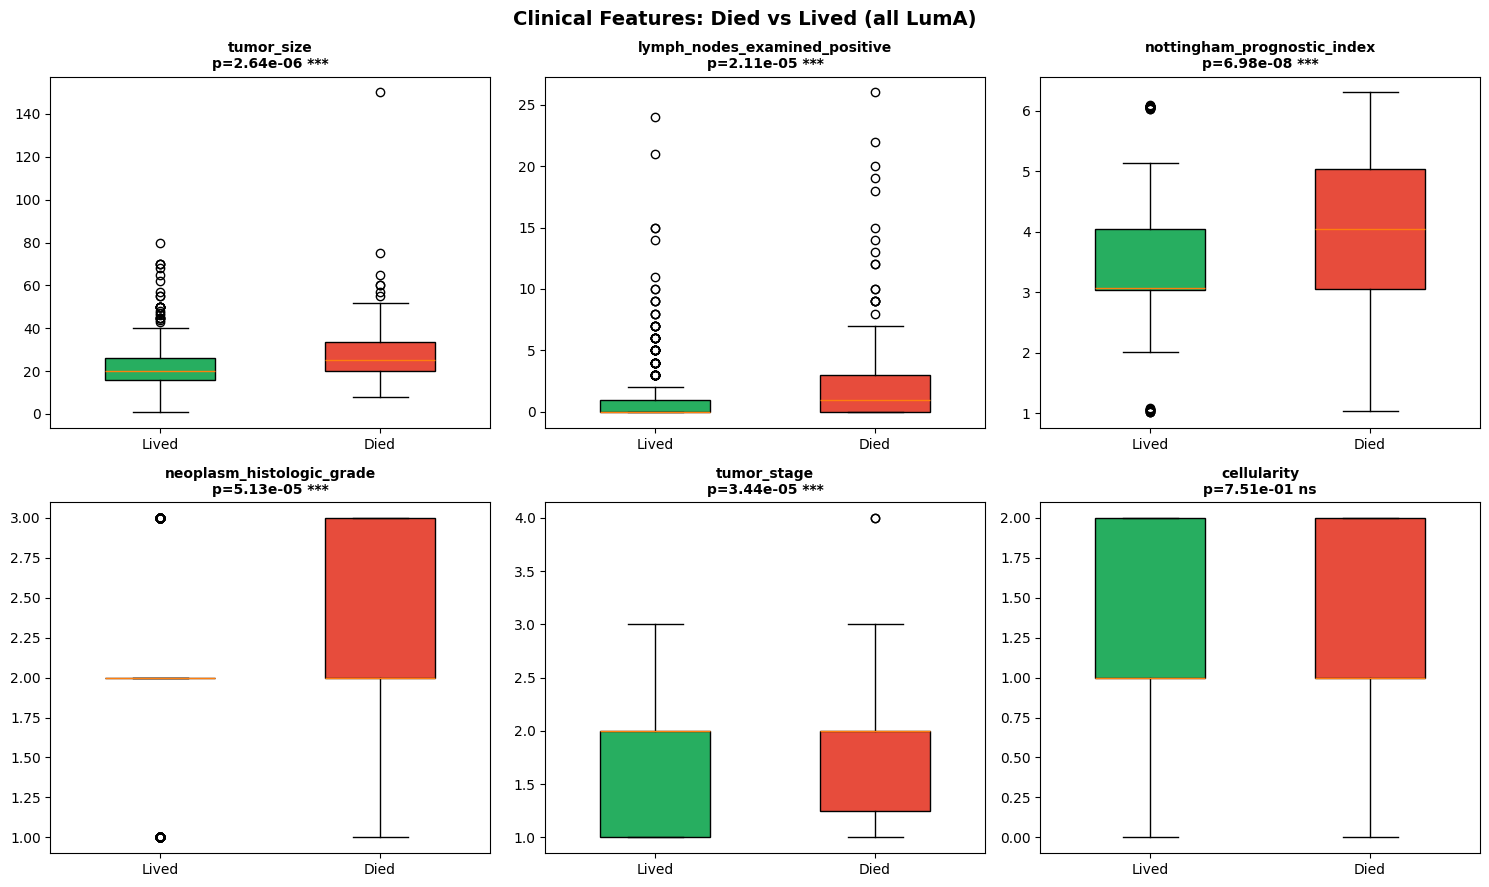

In [11]:
from scipy.stats import mannwhitneyu

numeric_clinical = [
    "tumor_size",
    "lymph_nodes_examined_positive",
    "nottingham_prognostic_index",
    "neoplasm_histologic_grade",
    "tumor_stage",
    "cellularity",
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
died = df_luma["target"] == 1
lived = df_luma["target"] == 0

for ax, col in zip(axes.flatten(), numeric_clinical):
    data = [df_luma.loc[lived, col].dropna(),
            df_luma.loc[died, col].dropna()]
    bp = ax.boxplot(data, labels=["Lived", "Died"], patch_artist=True,
                    widths=0.5)
    bp["boxes"][0].set_facecolor("#27AE60")
    bp["boxes"][1].set_facecolor("#E74C3C")

    _, p = mannwhitneyu(data[0], data[1])
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    ax.set_title(f"{col}\np={p:.2e} {sig}", fontweight="bold", fontsize=10)

plt.suptitle("Clinical Features: Died vs Lived (all LumA)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

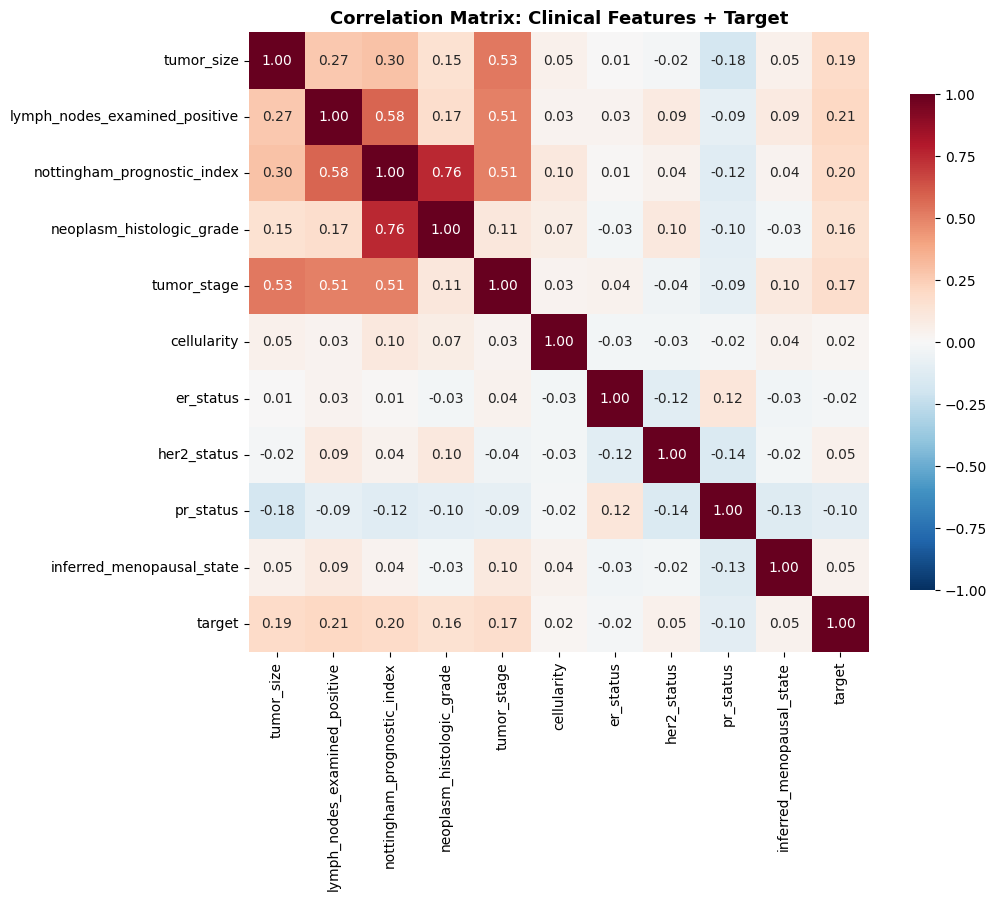

In [12]:
#corellation
import seaborn as sns

numeric_clinical = [
    "tumor_size",
    "lymph_nodes_examined_positive",
    "nottingham_prognostic_index",
    "neoplasm_histologic_grade",
    "tumor_stage",
    "cellularity",
    "er_status",
    "her2_status",
    "pr_status",
    "inferred_menopausal_state",
]

corr = df_luma[numeric_clinical + ["target"]].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="RdBu_r",
    center=0, vmin=-1, vmax=1, square=True,
    cbar_kws={"shrink": 0.8}, ax=ax,
)
ax.set_title("Correlation Matrix: Clinical Features + Target",
             fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

In [13]:
q1 = df_luma["tumor_size"].quantile(0.25)
q3 = df_luma["tumor_size"].quantile(0.75)
iqr = q3 - q1
low = q1 - 1.5 * iqr
high = q3 + 1.5 * iqr

n_outliers = ((df_luma["tumor_size"] < low) | (df_luma["tumor_size"] > high)).sum()
print(f"tumor_size: Q1={q1}, Q3={q3}, IQR={iqr}")
print(f"Normal range: [{low:.1f}, {high:.1f}] mm")
print(f"Outliers: {n_outliers}")

tumor_size: Q1=16.0, Q3=29.0, IQR=13.0
Normal range: [-3.5, 48.5] mm
Outliers: 32


In [14]:
outliers = df_luma[df_luma["tumor_size"] > 48.5]
print(f"Outliers: {len(outliers)}")
print(f"  Died: {outliers['target'].sum()} ({outliers['target'].mean()*100:.0f}%)")
print(f"  vs. Overall LumA death rate: 21.5%")
print(f"\nTumor size distribution of outliers:")
print(outliers["tumor_size"].describe())

Outliers: 32
  Died: 14 (44%)
  vs. Overall LumA death rate: 21.5%

Tumor size distribution of outliers:
count     32.000000
mean      60.187500
std       18.579277
min       49.000000
25%       50.000000
50%       55.000000
75%       65.000000
max      150.000000
Name: tumor_size, dtype: float64


In [15]:
#comment-> we keep all the data because it seems that the number of tumor size is real

In [16]:
#genes analysis
gene_data = df_luma[gene_cols]

print(f"Number of genes: {len(gene_cols)}")
print(f"Shape: {gene_data.shape}")
print(f"\nMissing values: {gene_data.isna().sum().sum()}")
print(f"\nOverall statistics:")
print(f"  Mean:   {gene_data.values.mean():.3f}")
print(f"  Std:    {gene_data.values.std():.3f}")
print(f"  Min:    {gene_data.values.min():.2f}")
print(f"  Max:    {gene_data.values.max():.2f}")

Number of genes: 489
Shape: (679, 489)

Missing values: 0

Overall statistics:
  Mean:   -0.015
  Std:    0.899
  Min:    -5.43
  Max:    15.30


In [17]:
#creating new feature
composite_features = [
    "tumor_size",
    "nottingham_prognostic_index",
    "lymph_nodes_examined_positive",
    "neoplasm_histologic_grade",
    "tumor_stage",
]

# Βάρη από το correlation matrix με target
weights = {
    "tumor_size": 0.19,
    "nottingham_prognostic_index": 0.20,
    "lymph_nodes_examined_positive": 0.21,
    "neoplasm_histologic_grade": 0.16,
    "tumor_stage": 0.17,
}

# Z-score κάθε μεταβλητής
z_scored = df_luma[composite_features].apply(
    lambda x: (x - x.mean()) / x.std()
)

# Weighted sum
df_luma["risk_score"] = sum(
    z_scored[col] * w for col, w in weights.items()
)

# Έλεγχος: συσχέτιση με target
corr_with_target = df_luma["risk_score"].corr(df_luma["target"])
print(f"risk_score correlation with target: {corr_with_target:.3f}")
print(f"\nrisk_score stats:")
print(df_luma["risk_score"].describe())

# Died vs Lived
print(f"\nDied:  mean={df_luma.loc[died, 'risk_score'].mean():.3f}")
print(f"Lived: mean={df_luma.loc[lived, 'risk_score'].mean():.3f}")

risk_score correlation with target: 0.260

risk_score stats:
count    678.000000
mean       0.000207
std        0.669544
min       -1.234469
25%       -0.502873
50%       -0.065419
75%        0.374085
max        3.911838
Name: risk_score, dtype: float64

Died:  mean=0.332
Lived: mean=-0.091


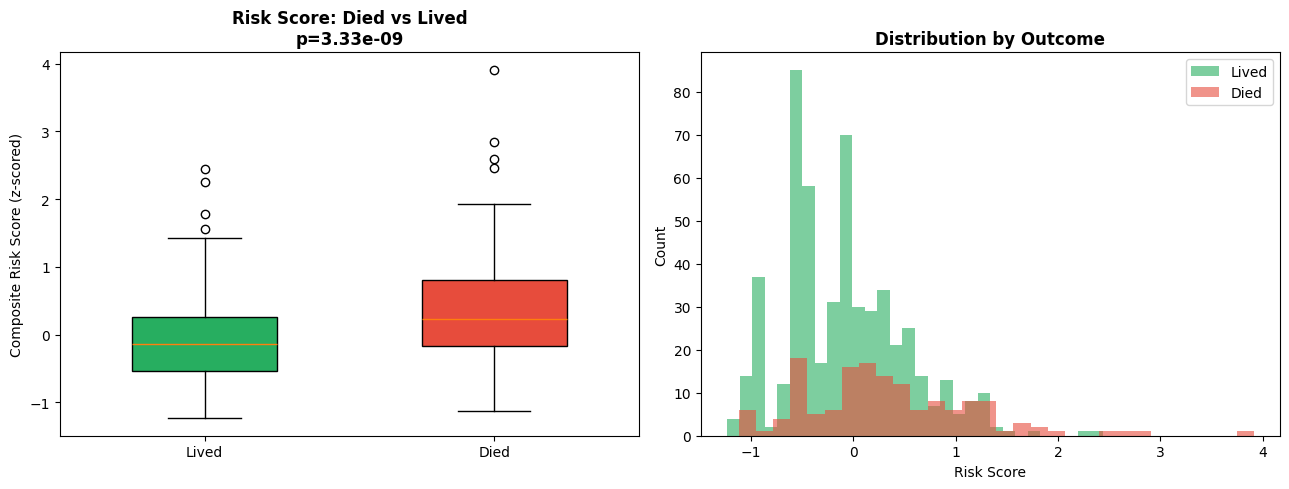

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Boxplot
data = [df_luma.loc[lived, "risk_score"].dropna(),
        df_luma.loc[died, "risk_score"].dropna()]
bp = axes[0].boxplot(data, tick_labels=["Lived", "Died"],
                     patch_artist=True, widths=0.5)
bp["boxes"][0].set_facecolor("#27AE60")
bp["boxes"][1].set_facecolor("#E74C3C")
_, p = mannwhitneyu(data[0], data[1])
axes[0].set_title(f"Risk Score: Died vs Lived\np={p:.2e}",
                  fontweight="bold")
axes[0].set_ylabel("Composite Risk Score (z-scored)")

# Histograms overlay
axes[1].hist(df_luma.loc[lived, "risk_score"].dropna(), bins=30,
             alpha=0.6, label="Lived", color="#27AE60")
axes[1].hist(df_luma.loc[died, "risk_score"].dropna(), bins=30,
             alpha=0.6, label="Died", color="#E74C3C")
axes[1].set_xlabel("Risk Score")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution by Outcome", fontweight="bold")
axes[1].legend()

plt.tight_layout()
plt.show()

In [19]:
gene_risk_corr = df_luma[gene_cols].corrwith(
    df_luma["risk_score"]
).sort_values(key=abs, ascending=False)

print(f"Top 20 genes most correlated with risk_score:")
print(gene_risk_corr.head(20))

print(f"\nSummary:")
print(f"  |corr| > 0.4: {(gene_risk_corr.abs() > 0.4).sum()} genes")
print(f"  |corr| > 0.3: {(gene_risk_corr.abs() > 0.3).sum()} genes")
print(f"  |corr| > 0.2: {(gene_risk_corr.abs() > 0.2).sum()} genes")

Top 20 genes most correlated with risk_score:
aurka     0.200945
spry2    -0.198158
gsk3b     0.189300
igf1r    -0.173149
hes6      0.172423
cdc25a    0.171170
e2f2      0.169718
diras3   -0.168712
stat1     0.168033
magea8    0.166277
tsc1     -0.163661
ncoa3     0.161712
kdm5a     0.154592
ccne1     0.154538
chek1     0.154371
bcl2     -0.154218
ccnb1     0.149133
acvr1    -0.148877
aph1b    -0.147051
runx1    -0.146121
dtype: float64

Summary:
  |corr| > 0.4: 0 genes
  |corr| > 0.3: 0 genes
  |corr| > 0.2: 1 genes


In [20]:
from scipy.stats import mannwhitneyu

died = df_luma["target"] == 1
lived = df_luma["target"] == 0

results = []
for gene in gene_cols:
    d_vals = df_luma.loc[died, gene]
    l_vals = df_luma.loc[lived, gene]
    _, p = mannwhitneyu(d_vals, l_vals, alternative="two-sided")
    results.append({
        "gene": gene,
        "died_mean": d_vals.mean(),
        "lived_mean": l_vals.mean(),
        "diff": d_vals.mean() - l_vals.mean(),
        "p_value": p,
    })

gene_eda = pd.DataFrame(results).sort_values("p_value")

print(f"Genes with p < 0.001: {(gene_eda['p_value'] < 0.001).sum()}")
print(f"Genes with p < 0.01:  {(gene_eda['p_value'] < 0.01).sum()}")
print(f"Genes with p < 0.05:  {(gene_eda['p_value'] < 0.05).sum()}")
print(f"\nTop 20 genes by p-value:")
print(gene_eda.head(20).to_string(index=False))

Genes with p < 0.001: 20
Genes with p < 0.01:  59
Genes with p < 0.05:  102

Top 20 genes by p-value:
   gene  died_mean  lived_mean      diff  p_value
  apaf1   0.058962   -0.198085  0.257048 0.000029
   e2f7  -0.254822   -0.526311  0.271489 0.000032
   e2f2  -0.423122   -0.668731  0.245609 0.000032
  aurka  -0.456551   -0.722843  0.266292 0.000033
  stat2   0.167393   -0.159537  0.326930 0.000042
 diras3  -0.046911    0.376806 -0.423717 0.000062
 stat5a  -0.196951    0.116144 -0.313095 0.000079
   pms2  -0.226184    0.119448 -0.345632 0.000101
  ccnb1  -0.276357   -0.522199  0.245842 0.000103
  gsk3b  -0.045757   -0.344038  0.298281 0.000109
   tbx3   0.109243    0.408290 -0.299047 0.000233
 notch3   0.263801   -0.020783  0.284585 0.000233
  ccne1  -0.463051   -0.583655  0.120605 0.000302
   e2f3  -0.242478   -0.488809  0.246331 0.000491
 cyp3a4  -0.292796    0.018840 -0.311636 0.000502
  kmt2c   0.168977   -0.096847  0.265824 0.000516
   tsc2   0.468379    0.163420  0.304959 0.00058

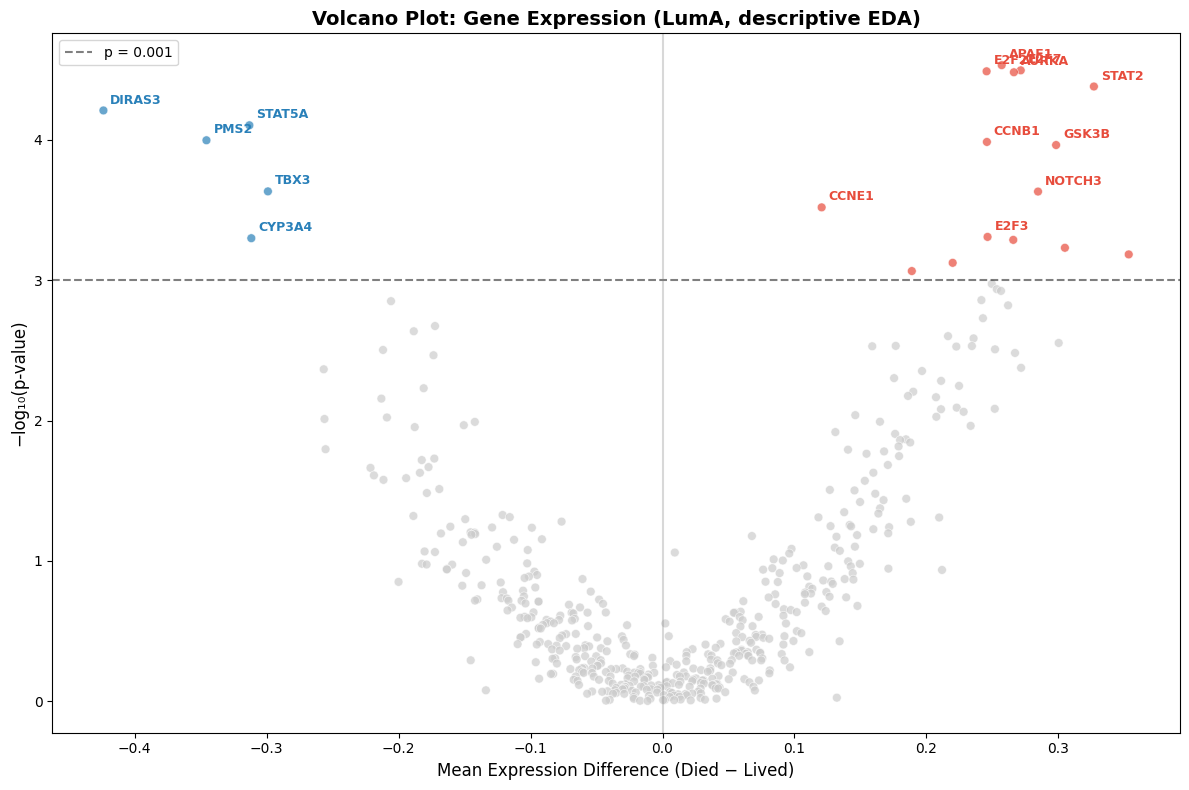

In [21]:
import numpy as np

fig, ax = plt.subplots(figsize=(12, 8))

gene_eda["neg_log10_p"] = -np.log10(gene_eda["p_value"])

# Χρωματισμός: κόκκινο = up in died, μπλε = down in died, γκρι = ns
colors = []
for _, row in gene_eda.iterrows():
    if row["p_value"] < 0.001 and row["diff"] > 0:
        colors.append("#E74C3C")  # up in died
    elif row["p_value"] < 0.001 and row["diff"] < 0:
        colors.append("#2980B9")  # down in died
    else:
        colors.append("#CCCCCC")  # not significant

ax.scatter(gene_eda["diff"], gene_eda["neg_log10_p"],
           c=colors, alpha=0.7, s=40, edgecolors="white", linewidth=0.5)

# Γραμμή p=0.001
ax.axhline(y=-np.log10(0.001), color="black", linestyle="--",
           alpha=0.5, label="p = 0.001")
ax.axvline(x=0, color="gray", alpha=0.3)

# Labels για top γονίδια
top_genes = gene_eda.head(15)
for _, row in top_genes.iterrows():
    color = "#E74C3C" if row["diff"] > 0 else "#2980B9"
    ax.annotate(
        row["gene"].upper(),
        (row["diff"], -np.log10(row["p_value"])),
        fontsize=9, fontweight="bold", color=color,
        xytext=(5, 5), textcoords="offset points",
    )

ax.set_xlabel("Mean Expression Difference (Died − Lived)", fontsize=12)
ax.set_ylabel("−log₁₀(p-value)", fontsize=12)
ax.set_title("Volcano Plot: Gene Expression (LumA, descriptive EDA)",
             fontsize=14, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

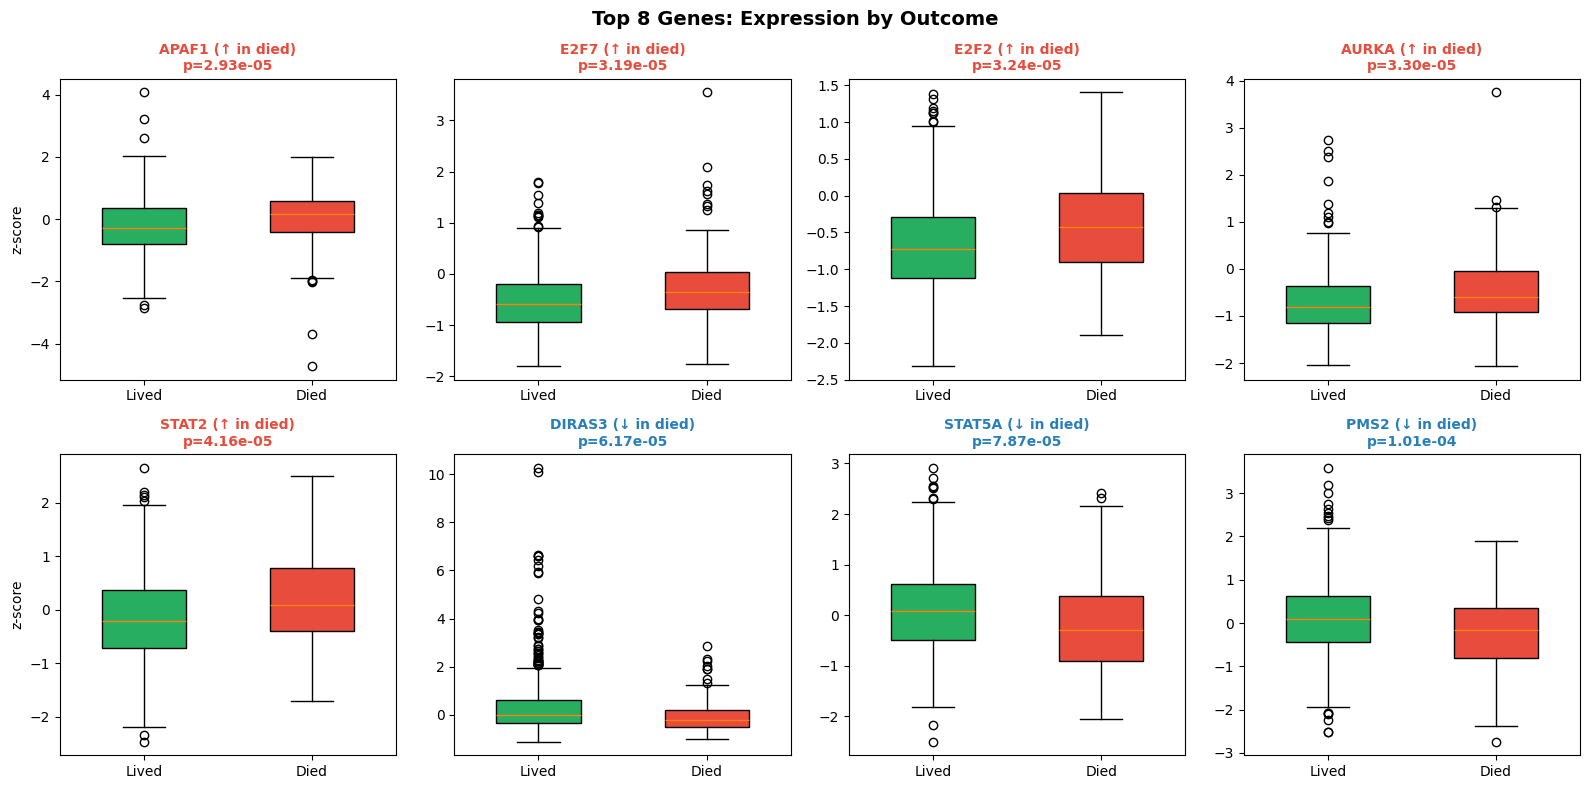

In [22]:
top_8 = gene_eda.head(8)["gene"].tolist()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, gene in zip(axes.flatten(), top_8):
    data = [df_luma.loc[lived, gene], df_luma.loc[died, gene]]
    bp = ax.boxplot(data, tick_labels=["Lived", "Died"],
                    patch_artist=True, widths=0.5)
    bp["boxes"][0].set_facecolor("#27AE60")
    bp["boxes"][1].set_facecolor("#E74C3C")

    p = gene_eda[gene_eda["gene"] == gene]["p_value"].values[0]
    diff = gene_eda[gene_eda["gene"] == gene]["diff"].values[0]
    direction = "↑ in died" if diff > 0 else "↓ in died"
    color = "#E74C3C" if diff > 0 else "#2980B9"
    ax.set_title(f"{gene.upper()} ({direction})\np={p:.2e}",
                 fontweight="bold", color=color, fontsize=10)
    ax.set_ylabel("z-score" if ax in axes[:, 0] else "")

plt.suptitle("Top 8 Genes: Expression by Outcome",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [23]:
# we see what is happening to those who has low risk_score
# Ορίζουμε χαμηλό risk score ως κάτω από τη διάμεσο
threshold = df_luma["risk_score"].median()

low_risk_died = df_luma[
    (df_luma["risk_score"] < threshold) & (df_luma["target"] == 1)
]
low_risk_lived = df_luma[
    (df_luma["risk_score"] < threshold) & (df_luma["target"] == 0)
]
high_risk_died = df_luma[
    (df_luma["risk_score"] >= threshold) & (df_luma["target"] == 1)
]
high_risk_lived = df_luma[
    (df_luma["risk_score"] >= threshold) & (df_luma["target"] == 0)
]

print(f"Risk score threshold (median): {threshold:.3f}")
print(f"\n                  Died    Lived")
print(f"Low risk score:   {len(low_risk_died):4d}    {len(low_risk_lived):4d}")
print(f"High risk score:  {len(high_risk_died):4d}    {len(high_risk_lived):4d}")
print(f"\nDiscordant deaths (low risk but died): {len(low_risk_died)}")

Risk score threshold (median): -0.065

                  Died    Lived
Low risk score:     46     293
High risk score:   100     239

Discordant deaths (low risk but died): 46


In [24]:
from scipy.stats import mannwhitneyu

# Γονίδια στους low-risk discordant vs low-risk lived
results = []
for gene in gene_cols:
    d_vals = low_risk_died[gene]
    l_vals = low_risk_lived[gene]
    _, p = mannwhitneyu(d_vals, l_vals, alternative="two-sided")
    results.append({
        "gene": gene,
        "died_mean": d_vals.mean(),
        "lived_mean": l_vals.mean(),
        "diff": d_vals.mean() - l_vals.mean(),
        "p_value": p,
    })

discordant_eda = pd.DataFrame(results).sort_values("p_value")

print(f"Discordant analysis (low risk, 46 died vs 293 lived)")
print(f"Genes with p < 0.001: {(discordant_eda['p_value'] < 0.001).sum()}")
print(f"Genes with p < 0.01:  {(discordant_eda['p_value'] < 0.01).sum()}")
print(f"Genes with p < 0.05:  {(discordant_eda['p_value'] < 0.05).sum()}")
print(f"\nTop 20 discordant genes:")
print(discordant_eda.head(20).to_string(index=False))

Discordant analysis (low risk, 46 died vs 293 lived)
Genes with p < 0.001: 3
Genes with p < 0.01:  19
Genes with p < 0.05:  64

Top 20 discordant genes:
    gene  died_mean  lived_mean      diff  p_value
  stat5a  -0.464970    0.144758 -0.609727 0.000022
   mmp11   0.475304   -0.063592  0.538896 0.000032
 col22a1   0.037796   -0.273513  0.311309 0.000622
  diras3  -0.055913    0.527100 -0.583013 0.002201
     bmf   0.212283   -0.175437  0.387719 0.002386
   gsk3b  -0.114667   -0.466467  0.351800 0.002670
  notch3   0.342161   -0.040855  0.383016 0.002913
   stat2   0.165661   -0.182983  0.348644 0.004095
  pdgfrb   0.594943    0.217908  0.377036 0.004686
   pdgfb   0.203911   -0.180963  0.384874 0.004746
   mmp26  -0.358454    0.050643 -0.409097 0.005118
    itch  -0.231609    0.132328 -0.363937 0.005234
  stat5b   0.098293    0.391863 -0.293569 0.007156
   ccne1  -0.489939   -0.631577  0.141638 0.007529
   aph1b   0.406867    0.695881 -0.289013 0.008053
  rassf1  -0.460133   -0.053209

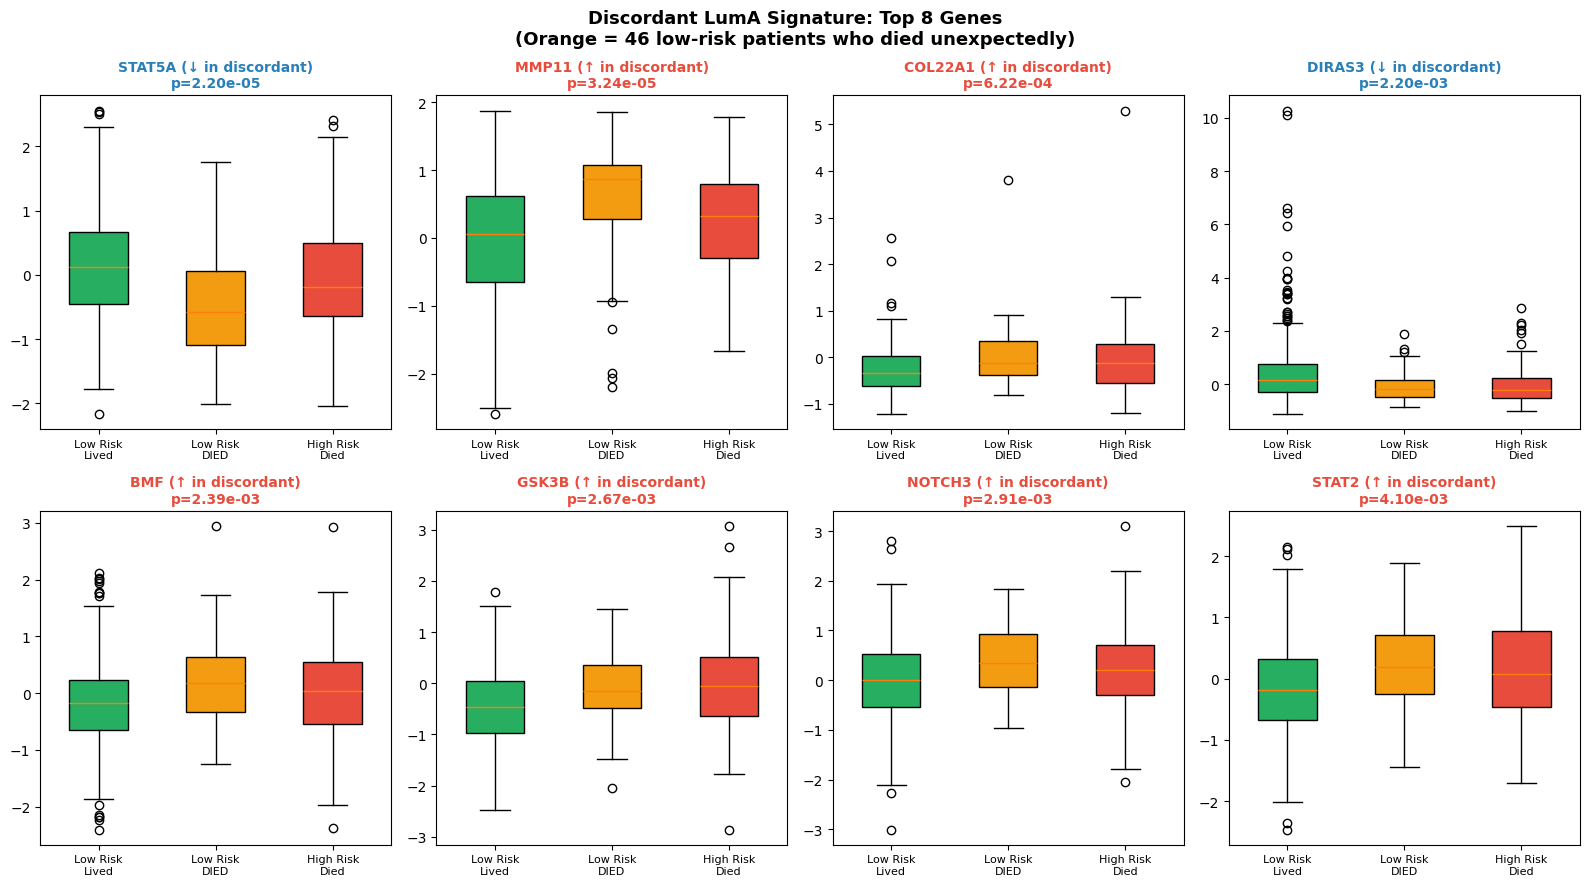

In [25]:
top_8_disc = discordant_eda.head(8)["gene"].tolist()

# Τρεις ομάδες: low-risk died, low-risk lived, high-risk died
fig, axes = plt.subplots(2, 4, figsize=(16, 9))

for ax, gene in zip(axes.flatten(), top_8_disc):
    data = [
        low_risk_lived[gene],
        low_risk_died[gene],
        high_risk_died[gene],
    ]
    bp = ax.boxplot(
        data,
        tick_labels=["Low Risk\nLived", "Low Risk\nDIED", "High Risk\nDied"],
        patch_artist=True, widths=0.5,
    )
    bp["boxes"][0].set_facecolor("#27AE60")
    bp["boxes"][1].set_facecolor("#F39C12")  # πορτοκαλί για discordant
    bp["boxes"][2].set_facecolor("#E74C3C")

    p = discordant_eda[discordant_eda["gene"] == gene]["p_value"].values[0]
    diff = discordant_eda[discordant_eda["gene"] == gene]["diff"].values[0]
    direction = "↑ in discordant" if diff > 0 else "↓ in discordant"
    color = "#E74C3C" if diff > 0 else "#2980B9"
    ax.set_title(f"{gene.upper()} ({direction})\np={p:.2e}",
                 fontweight="bold", color=color, fontsize=10)
    ax.tick_params(axis="x", labelsize=8)

plt.suptitle(
    "Discordant LumA Signature: Top 8 Genes\n"
    "(Orange = 46 low-risk patients who died unexpectedly)",
    fontsize=13, fontweight="bold",
)
plt.tight_layout()
plt.show()

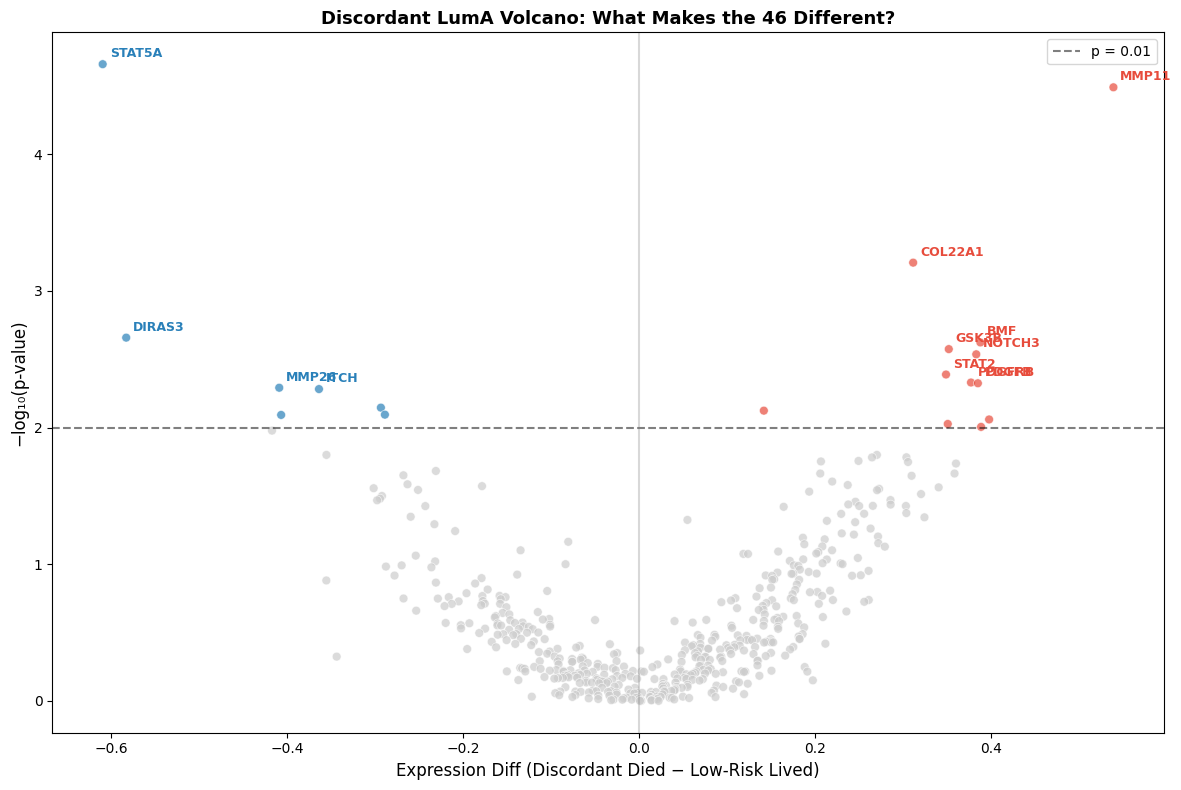

In [26]:
fig, ax = plt.subplots(figsize=(12, 8))

discordant_eda["neg_log10_p"] = -np.log10(discordant_eda["p_value"])

colors = []
for _, row in discordant_eda.iterrows():
    if row["p_value"] < 0.01 and row["diff"] > 0:
        colors.append("#E74C3C")
    elif row["p_value"] < 0.01 and row["diff"] < 0:
        colors.append("#2980B9")
    else:
        colors.append("#CCCCCC")

ax.scatter(discordant_eda["diff"], discordant_eda["neg_log10_p"],
           c=colors, alpha=0.7, s=40, edgecolors="white", linewidth=0.5)

ax.axhline(y=-np.log10(0.01), color="black", linestyle="--",
           alpha=0.5, label="p = 0.01")
ax.axvline(x=0, color="gray", alpha=0.3)

top_disc = discordant_eda.head(12)
for _, row in top_disc.iterrows():
    color = "#E74C3C" if row["diff"] > 0 else "#2980B9"
    ax.annotate(
        row["gene"].upper(),
        (row["diff"], -np.log10(row["p_value"])),
        fontsize=9, fontweight="bold", color=color,
        xytext=(5, 5), textcoords="offset points",
    )

ax.set_xlabel("Expression Diff (Discordant Died − Low-Risk Lived)",
              fontsize=12)
ax.set_ylabel("−log₁₀(p-value)", fontsize=12)
ax.set_title("Discordant LumA Volcano: What Makes the 46 Different?",
             fontweight="bold", fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

In [27]:
#"While the general LumA mortality signature is dominated by proliferation markers (AURKA, E2F family, cyclins) consistent with clinically apparent aggressive disease, a distinct subset of 46 patients who died despite low clinical risk scores exhibits a fundamentally different molecular profile characterized by invasion and stromal remodeling (MMP11, COL22A1, FN1, PDGFRB) combined with loss of luminal identity (STAT5A ↓, DIRAS3 ↓). This 'silent metastatic' signature cannot be detected by standard clinico-pathological assessment and represents a critical unmet need for molecular screening in clinically reassuring LumA cases."

In [28]:
#analysis of mutations
from scipy.stats import fisher_exact

died = df_luma["target"] == 1
lived = df_luma["target"] == 0
n_died = died.sum()
n_lived = lived.sum()

results = []
for col in mutation_cols:
    died_mut = df_luma.loc[died, col].sum()
    lived_mut = df_luma.loc[lived, col].sum()
    if (died_mut + lived_mut) >= 5:  # τουλάχιστον 5 ασθενείς με μετάλλαξη
        table = [
            [died_mut, n_died - died_mut],
            [lived_mut, n_lived - lived_mut],
        ]
        odds_ratio, p = fisher_exact(table)
        results.append({
            "mutation": col.replace("_mut", "").upper(),
            "column": col,
            "died_pct": died_mut / n_died * 100,
            "lived_pct": lived_mut / n_lived * 100,
            "odds_ratio": odds_ratio,
            "p_value": p,
        })

mut_eda = pd.DataFrame(results).sort_values("p_value")

print(f"Mutations tested (>=5 events): {len(mut_eda)}")
print(f"Mutations with p < 0.05: {(mut_eda['p_value'] < 0.05).sum()}")
print(f"\nTop 15 mutations by p-value:")
print(mut_eda.head(15).to_string(index=False))

Mutations tested (>=5 events): 134
Mutations with p < 0.05: 7

Top 15 mutations by p-value:
mutation      column  died_pct  lived_pct  odds_ratio  p_value
   ASXL2   asxl2_mut  7.534247   1.688555    4.744033 0.000893
   L1CAM   l1cam_mut  4.109589   0.750469    5.667857 0.008756
   MYO3A   myo3a_mut  4.109589   0.938086    4.525714 0.015878
    TP53    tp53_mut 17.808219  10.318949    1.883030 0.020265
   NCOR2   ncor2_mut  1.369863   5.628518    0.232870 0.027822
   GATA3   gata3_mut 13.698630  21.200750    0.589971 0.045522
    TBX3    tbx3_mut  3.424658   8.255159    0.394101 0.047176
 COL22A1 col22a1_mut  7.534247   3.939962    1.986596 0.078608
    SIK1    sik1_mut  2.739726   0.938086    2.974648 0.105368
  ARID1A  arid1a_mut  6.849315   3.752345    1.886029 0.113840
   PBRM1   pbrm1_mut  2.054795   0.562852    3.706294 0.117275
 DCAF4L2 dcaf4l2_mut  2.054795   0.562852    3.706294 0.117275
   FBXW7   fbxw7_mut  2.054795   0.562852    3.706294 0.117275
    PTEN    pten_mut  6.16

In [29]:
#mutations at low risk_score patients
# Μεταλλάξεις στους 46 discordant vs 293 low-risk lived
n_disc = len(low_risk_died)
n_lr_lived = len(low_risk_lived)

results = []
for col in mutation_cols:
    disc_mut = low_risk_died[col].sum()
    lived_mut = low_risk_lived[col].sum()
    if (disc_mut + lived_mut) >= 3:
        table = [
            [disc_mut, n_disc - disc_mut],
            [lived_mut, n_lr_lived - lived_mut],
        ]
        odds_ratio, p = fisher_exact(table)
        results.append({
            "mutation": col.replace("_mut", "").upper(),
            "disc_pct": disc_mut / n_disc * 100,
            "lived_pct": lived_mut / n_lr_lived * 100,
            "odds_ratio": odds_ratio,
            "p_value": p,
        })

mut_disc = pd.DataFrame(results).sort_values("p_value")
print(f"Mutations tested: {len(mut_disc)}")
print(f"p < 0.05: {(mut_disc['p_value'] < 0.05).sum()}")
print(f"\nTop 15 discordant mutations:")
print(mut_disc.head(15).to_string(index=False))

Mutations tested: 131
p < 0.05: 4

Top 15 discordant mutations:
mutation  disc_pct  lived_pct  odds_ratio  p_value
     RB1  6.521739   0.682594   10.151163 0.019286
    PTEN  8.695652   1.706485    5.485714 0.022481
  MAGEA8  4.347826   0.341297   13.272727 0.049480
    SGCD  4.347826   0.341297   13.272727 0.049480
   ERBB4  6.521739   1.365188    5.040698 0.055312
  ADGRA2  6.521739   1.365188    5.040698 0.055312
      TG  0.000000   8.191126    0.000000 0.056699
   ASXL2  6.521739   1.706485    4.018605 0.080179
  MAP2K4 13.043478   6.143345    2.291667 0.115232
   MYO1A  4.347826   1.023891    4.393939 0.137859
   ERBB3  4.347826   1.023891    4.393939 0.137859
   SMAD4  4.347826   1.023891    4.393939 0.137859
    TP53 15.217391   7.849829    2.107023 0.155906
   ARID2  4.347826   1.365188    3.284091 0.189335
    AGMO  4.347826   1.365188    3.284091 0.189335


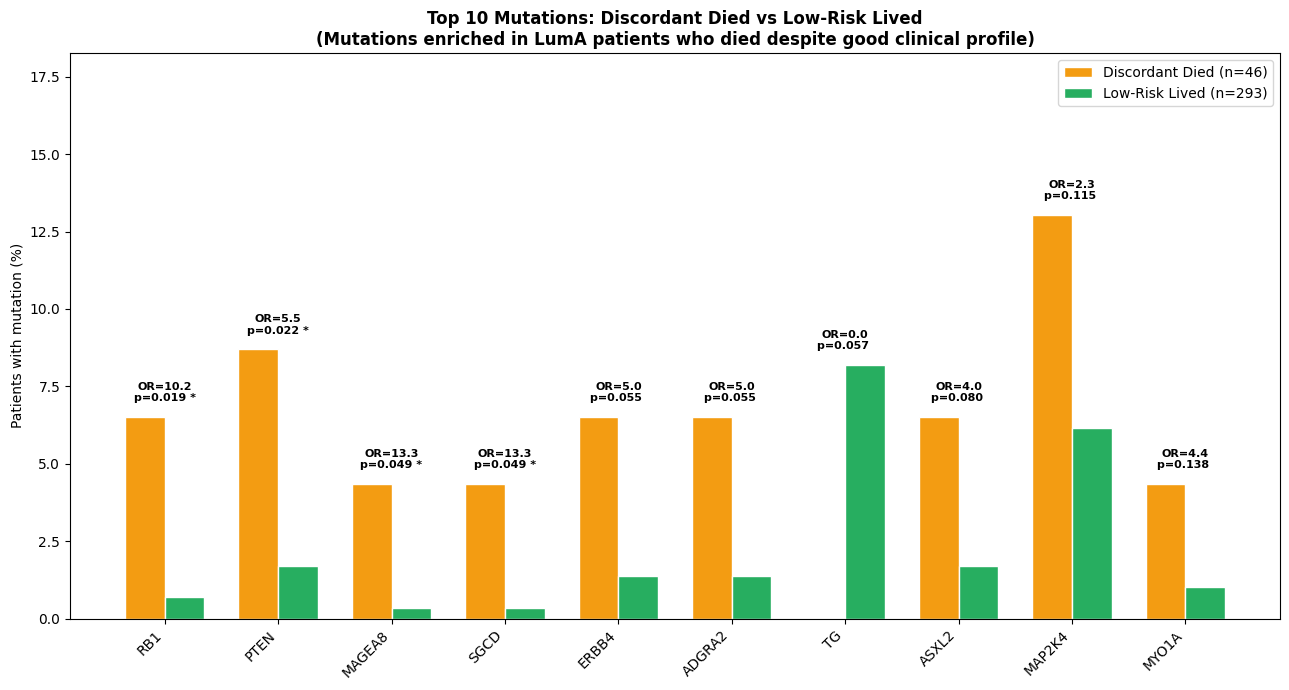

In [30]:
top_muts = mut_disc.head(10)

fig, ax = plt.subplots(figsize=(13, 7))

x = np.arange(len(top_muts))
width = 0.35

bars1 = ax.bar(
    x - width/2, top_muts["disc_pct"], width,
    label=f"Discordant Died (n={len(low_risk_died)})",
    color="#F39C12", edgecolor="white",
)
bars2 = ax.bar(
    x + width/2, top_muts["lived_pct"], width,
    label=f"Low-Risk Lived (n={len(low_risk_lived)})",
    color="#27AE60", edgecolor="white",
)

# Annotate p-values and odds ratios
for i, (_, row) in enumerate(top_muts.iterrows()):
    max_h = max(row["disc_pct"], row["lived_pct"])
    sig = "***" if row["p_value"] < 0.001 else (
        "**" if row["p_value"] < 0.01 else (
            "*" if row["p_value"] < 0.05 else ""))
    ax.text(
        i, max_h + 0.5,
        f"OR={row['odds_ratio']:.1f}\np={row['p_value']:.3f} {sig}",
        ha="center", fontsize=8, fontweight="bold",
    )

ax.set_xticks(x)
ax.set_xticklabels(top_muts["mutation"], rotation=45, ha="right")
ax.set_ylabel("Patients with mutation (%)")
ax.set_title(
    "Top 10 Mutations: Discordant Died vs Low-Risk Lived\n"
    "(Mutations enriched in LumA patients who died despite good clinical profile)",
    fontweight="bold", fontsize=12,
)
ax.legend(loc="upper right")
ax.set_ylim(0, max(top_muts[["disc_pct", "lived_pct"]].max()) * 1.4)
plt.tight_layout()
plt.show()

In [31]:
#comment->"Somatic mutations in RB1 (10× enrichment) and PTEN (5× enrichment) identify a molecular subset of clinically-reassuring LumA patients with fatal outcomes. These mutations provide mechanistic explanation for the transcriptomic signature: RB1 loss activates E2F-driven proliferation, while PTEN loss enables estrogen-independent survival, together producing a silent metastatic phenotype despite favorable pathological features."

In [32]:
key_muts = ["rb1_mut", "pten_mut"]

# Στους 46 discordant
disc_with_any = (low_risk_died[key_muts].sum(axis=1) > 0).sum()
disc_with_rb1 = low_risk_died["rb1_mut"].sum()
disc_with_pten = low_risk_died["pten_mut"].sum()
disc_with_both = ((low_risk_died["rb1_mut"] == 1) & 
                  (low_risk_died["pten_mut"] == 1)).sum()

# Στους 293 low-risk lived (control)
lived_with_any = (low_risk_lived[key_muts].sum(axis=1) > 0).sum()

print(f"Discordant patients (n=46):")
print(f"  RB1 mutated:        {disc_with_rb1} ({disc_with_rb1/46*100:.1f}%)")
print(f"  PTEN mutated:       {disc_with_pten} ({disc_with_pten/46*100:.1f}%)")
print(f"  Both RB1 + PTEN:    {disc_with_both}")
print(f"  At least one:       {disc_with_any} ({disc_with_any/46*100:.1f}%)")
print()
print(f"Low-risk lived (n=293):")
print(f"  At least one:       {lived_with_any} ({lived_with_any/293*100:.1f}%)")
print()
print(f"Enrichment: {(disc_with_any/46) / (lived_with_any/293):.1f}x")

Discordant patients (n=46):
  RB1 mutated:        3 (6.5%)
  PTEN mutated:       4 (8.7%)
  Both RB1 + PTEN:    0
  At least one:       7 (15.2%)

Low-risk lived (n=293):
  At least one:       7 (2.4%)

Enrichment: 6.4x


In [33]:
#creating new feutures with gens and muts
def make_composite(genes_df, muts_df, df, col_name):
    """Create weighted composite from gene expression + mutations.

    Genes: z-scored, signed by direction (+1 if up in discordant, -1 if down).
    Mutations: binary (0/1), signed by odds ratio (+1 if enriched in discordant).
    """
    score = pd.Series(0.0, index=df.index)

    # Gene expression component
    for _, row in genes_df.iterrows():
        gene = row["gene"]
        vals = df[gene]
        z = (vals - vals.mean()) / vals.std()
        sign = 1 if row["diff"] > 0 else -1
        score += sign * z

    # Mutation component
    for _, row in muts_df.iterrows():
        mut_col = row["column"] if "column" in row else row["mutation"].lower() + "_mut"
        if mut_col in df.columns:
            sign = 1 if row["odds_ratio"] > 1 else -1
            score += sign * df[mut_col]

    df[col_name] = score
    return score


# Για discordant analysis — χρειαζόμαστε το column name στα mutations
mut_disc["column"] = mut_disc["mutation"].str.lower() + "_mut"

# Subsets με p-value thresholds
genes_001 = discordant_eda[discordant_eda["p_value"] < 0.001]
genes_01 = discordant_eda[discordant_eda["p_value"] < 0.01]
genes_05 = discordant_eda[discordant_eda["p_value"] < 0.05]
muts_05 = mut_disc[mut_disc["p_value"] < 0.05]
empty_df = pd.DataFrame(columns=["mutation", "column", "odds_ratio"])

# Composites
make_composite(genes_001, empty_df, df_luma, "disc_g001")
make_composite(genes_01, empty_df, df_luma, "disc_g01")
make_composite(genes_05, empty_df, df_luma, "disc_g05")
make_composite(pd.DataFrame(columns=["gene", "diff"]), muts_05, df_luma, "disc_m05")
make_composite(genes_001, muts_05, df_luma, "disc_g001_m05")
make_composite(genes_01, muts_05, df_luma, "disc_g01_m05")
make_composite(genes_05, muts_05, df_luma, "disc_g05_m05")

# Έλεγχος: συσχέτιση με target
composites = ["disc_g001", "disc_g01", "disc_g05", "disc_m05",
              "disc_g001_m05", "disc_g01_m05", "disc_g05_m05"]

print(f"{'Composite':18s} {'#Genes':>7s} {'#Muts':>6s} "
      f"{'Corr w/target':>15s} {'Died mean':>11s} {'Lived mean':>12s}")
print("=" * 75)

sizes = {
    "disc_g001":     (len(genes_001), 0),
    "disc_g01":      (len(genes_01), 0),
    "disc_g05":      (len(genes_05), 0),
    "disc_m05":      (0, len(muts_05)),
    "disc_g001_m05": (len(genes_001), len(muts_05)),
    "disc_g01_m05":  (len(genes_01), len(muts_05)),
    "disc_g05_m05":  (len(genes_05), len(muts_05)),
}

for col in composites:
    n_g, n_m = sizes[col]
    corr = df_luma[col].corr(df_luma["target"])
    d_mean = df_luma.loc[died, col].mean()
    l_mean = df_luma.loc[lived, col].mean()
    print(f"{col:18s} {n_g:>7d} {n_m:>6d} "
          f"{corr:>15.3f} {d_mean:>11.2f} {l_mean:>12.2f}")

Composite           #Genes  #Muts   Corr w/target   Died mean   Lived mean
disc_g001                3      0           0.192        0.72        -0.20
disc_g01                19      0           0.257        3.77        -1.03
disc_g05                64      0           0.286       10.11        -2.77
disc_m05                 0      4           0.101        0.11         0.05
disc_g001_m05            3      4           0.202        0.83        -0.15
disc_g01_m05            19      4           0.259        3.88        -0.99
disc_g05_m05            64      4           0.287       10.22        -2.72


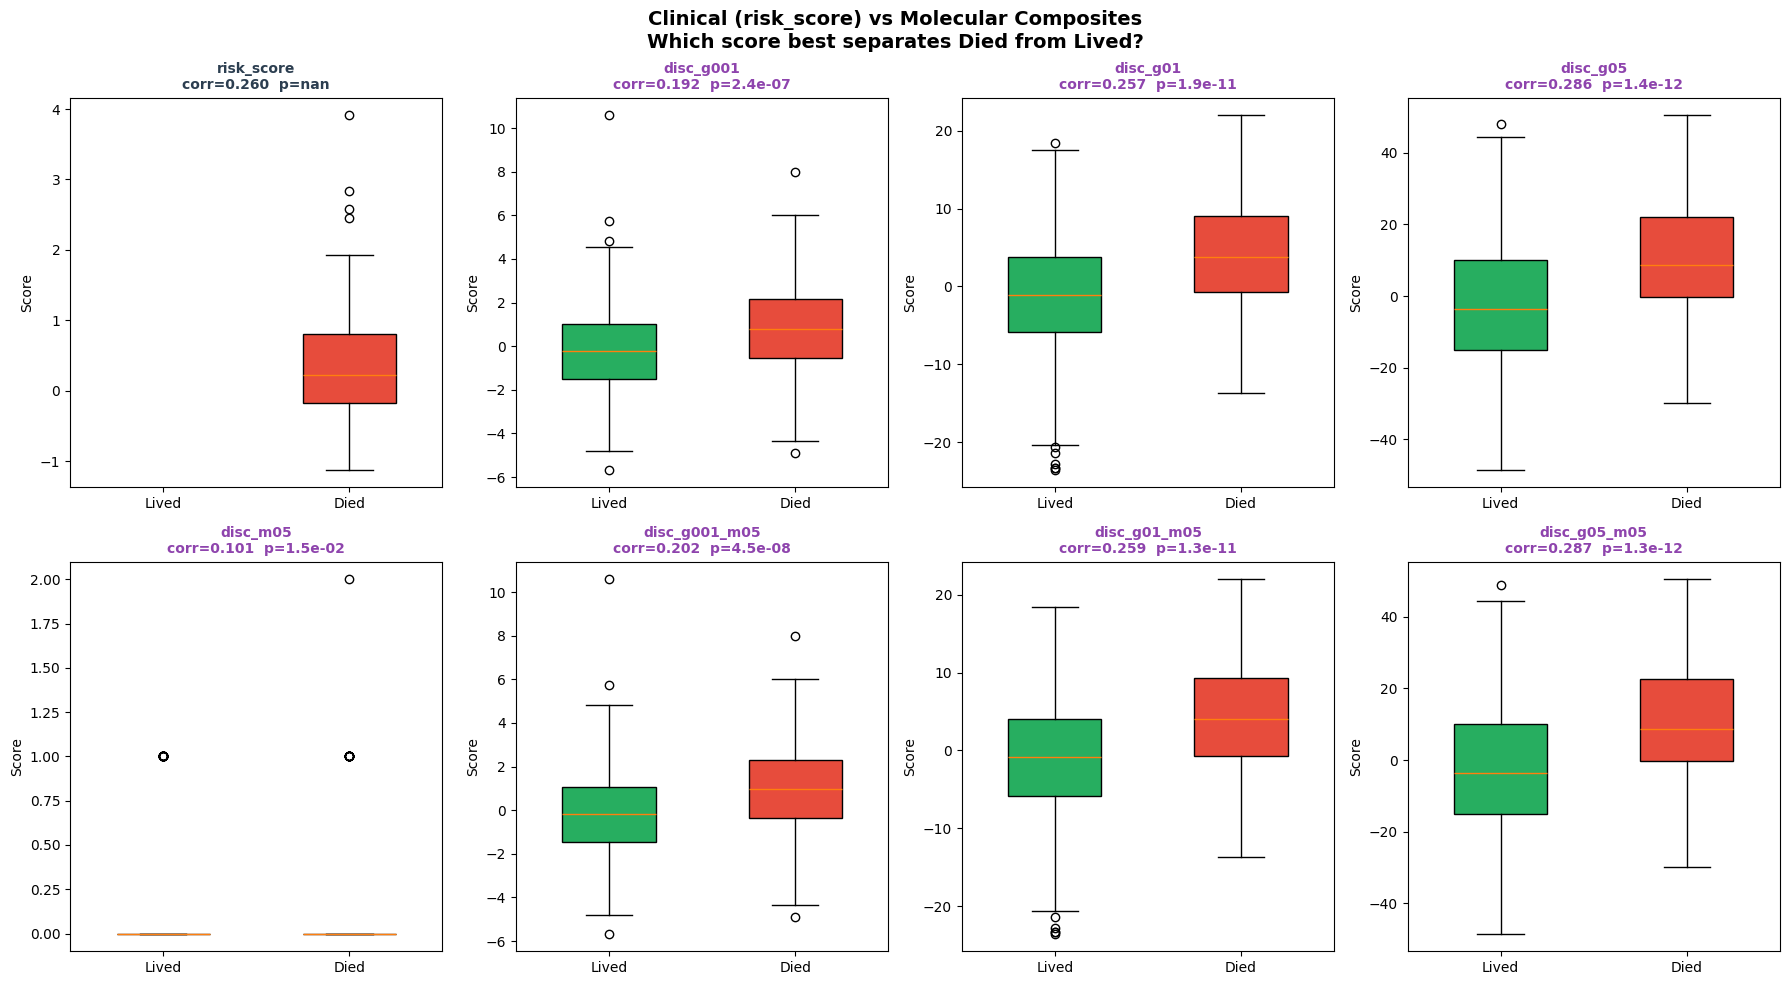

In [34]:
all_scores = ["risk_score", "disc_g001", "disc_g01", "disc_g05",
              "disc_m05", "disc_g001_m05", "disc_g01_m05", "disc_g05_m05"]

fig, axes = plt.subplots(2, 4, figsize=(18, 10))

for ax, score_col in zip(axes.flatten(), all_scores):
    data = [df_luma.loc[lived, score_col], df_luma.loc[died, score_col]]
    bp = ax.boxplot(data, tick_labels=["Lived", "Died"],
                    patch_artist=True, widths=0.5)
    bp["boxes"][0].set_facecolor("#27AE60")
    bp["boxes"][1].set_facecolor("#E74C3C")

    _, p = mannwhitneyu(data[0], data[1])
    corr = df_luma[score_col].corr(df_luma["target"])

    title_color = "#2C3E50" if score_col == "risk_score" else "#8E44AD"
    ax.set_title(
        f"{score_col}\ncorr={corr:.3f}  p={p:.1e}",
        fontweight="bold", color=title_color, fontsize=10,
    )
    ax.set_ylabel("Score")

plt.suptitle(
    "Clinical (risk_score) vs Molecular Composites\n"
    "Which score best separates Died from Lived?",
    fontsize=14, fontweight="bold",
)
plt.tight_layout()
plt.show()

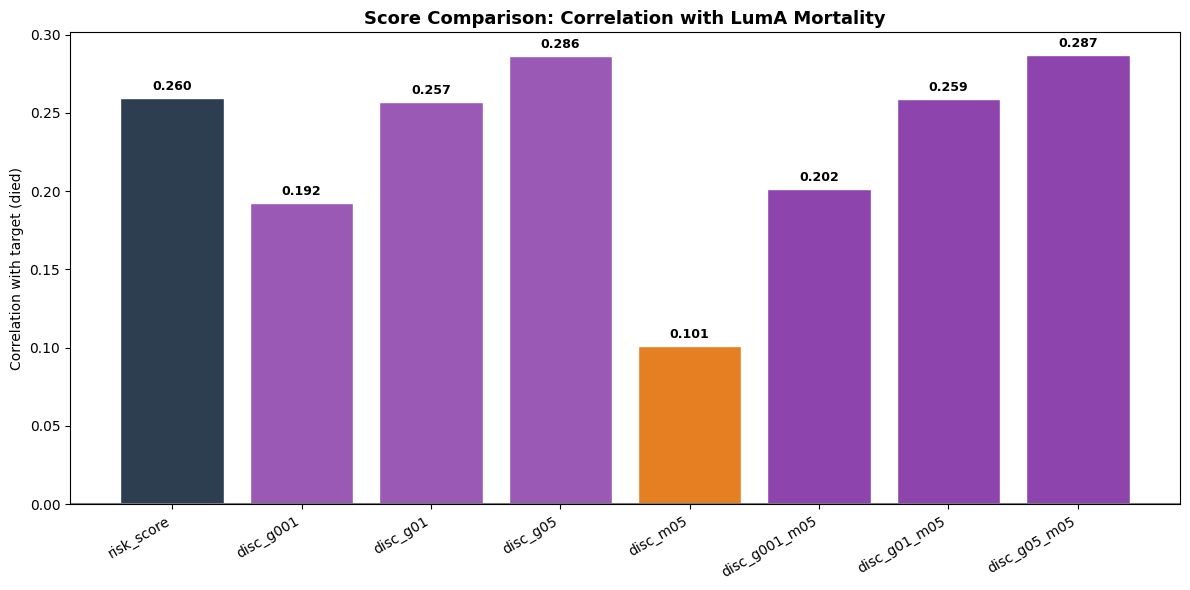

In [35]:
correlations = {col: df_luma[col].corr(df_luma["target"]) for col in all_scores}

fig, ax = plt.subplots(figsize=(12, 6))
colors_bar = ["#2C3E50"] + ["#9B59B6"] * 3 + ["#E67E22"] + ["#8E44AD"] * 3
bars = ax.bar(
    correlations.keys(), correlations.values(),
    color=colors_bar, edgecolor="white",
)
ax.axhline(y=0, color="gray")
ax.set_ylabel("Correlation with target (died)")
ax.set_title(
    "Score Comparison: Correlation with LumA Mortality",
    fontweight="bold", fontsize=13,
)

for bar, val in zip(bars, correlations.values()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.005,
        f"{val:.3f}",
        ha="center", fontweight="bold", fontsize=9,
    )

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [36]:
# Fix NaN στο risk_score
df_luma["risk_score"] = df_luma["risk_score"].fillna(df_luma["risk_score"].median())

# Combined score: κλινικό + μοριακό
# Z-score each first so they contribute equally
rs_z = (df_luma["risk_score"] - df_luma["risk_score"].mean()) / df_luma["risk_score"].std()
mol_z = (df_luma["disc_g05"] - df_luma["disc_g05"].mean()) / df_luma["disc_g05"].std()
df_luma["combined_score"] = rs_z + mol_z

corr_combined = df_luma["combined_score"].corr(df_luma["target"])
print(f"risk_score only:    0.260")
print(f"disc_g05 only:      0.286")
print(f"Combined (rs+g05):  {corr_combined:.3f}")

risk_score only:    0.260
disc_g05 only:      0.286
Combined (rs+g05):  0.363


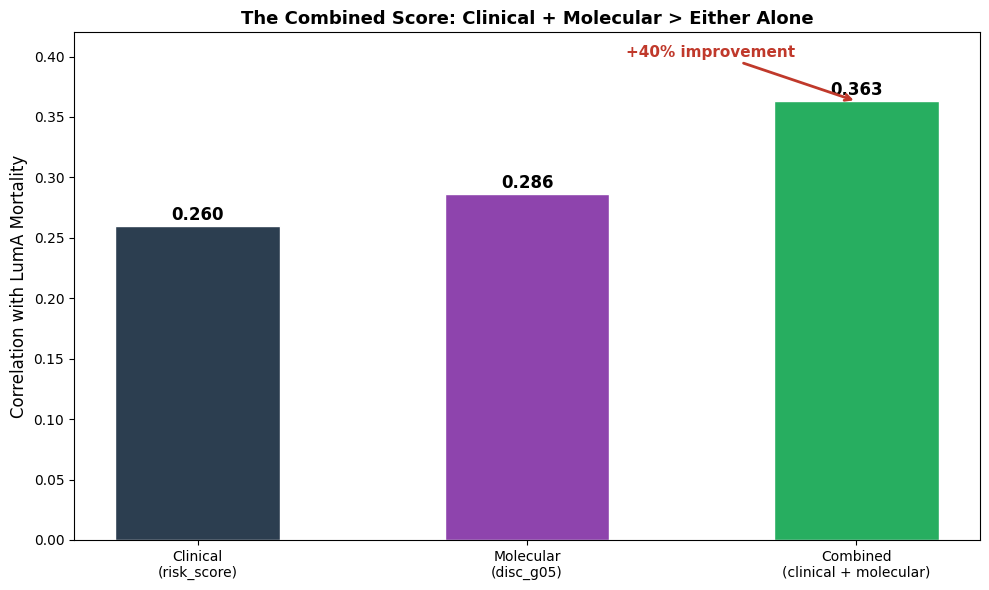

In [37]:
fig, ax = plt.subplots(figsize=(10, 6))

scores_final = {
    "Clinical\n(risk_score)": 0.260,
    "Molecular\n(disc_g05)": 0.286,
    "Combined\n(clinical + molecular)": 0.363,
}

colors_final = ["#2C3E50", "#8E44AD", "#27AE60"]
bars = ax.bar(
    scores_final.keys(), scores_final.values(),
    color=colors_final, edgecolor="white", width=0.5,
)

for bar, val in zip(bars, scores_final.values()):
    ax.text(
        bar.get_x() + bar.get_width() / 2, val + 0.005,
        f"{val:.3f}", ha="center",
        fontweight="bold", fontsize=12,
    )

ax.set_ylabel("Correlation with LumA Mortality", fontsize=12)
ax.set_title(
    "The Combined Score: Clinical + Molecular > Either Alone",
    fontsize=13, fontweight="bold",
)
ax.set_ylim(0, 0.42)

# Arrow showing improvement
ax.annotate(
    "+40% improvement", xy=(2, 0.363), xytext=(1.3, 0.40),
    fontsize=11, fontweight="bold", color="#C0392B",
    arrowprops=dict(arrowstyle="->", color="#C0392B", lw=2),
)

plt.tight_layout()
plt.show()

In [38]:
#non LumA patients
# Πάρε όλους τους μη-LumA από το αρχικό df
df_other = df[df["pam50_+_claudin-low_subtype"] != "LumA"].copy()

# Target
df_other["target"] = df_other["death_from_cancer"].apply(
    lambda x: 1 if str(x).strip().lower() == "died of disease" else 0
)

# Binarize mutations
for col in mutation_cols:
    if col in df_other.columns:
        df_other[col] = df_other[col].apply(
            lambda x: 0 if pd.isna(x) or str(x).strip() == "0" else 1
        )

print(f"Non-LumA patients: {len(df_other)}")
print(f"\nBreakdown by subtype:")
print(df_other["pam50_+_claudin-low_subtype"].value_counts())
print(f"\nOverall death rate: {df_other['target'].mean()*100:.1f}%")
print(f"Death rate by subtype:")
print(df_other.groupby("pam50_+_claudin-low_subtype")["target"].mean().round(3) * 100)

Non-LumA patients: 1225

Breakdown by subtype:
pam50_+_claudin-low_subtype
LumB           461
Her2           220
claudin-low    199
Basal          199
Normal         140
NC               6
Name: count, dtype: int64

Overall death rate: 38.9%
Death rate by subtype:
pam50_+_claudin-low_subtype
Basal          40.7
Her2           48.6
LumB           39.3
NC             50.0
Normal         34.3
claudin-low    28.1
Name: target, dtype: float64


In [39]:
# 1. Risk score (clinical) — ίδια βάρη
composite_features = [
    "tumor_size",
    "nottingham_prognostic_index",
    "lymph_nodes_examined_positive",
    "neoplasm_histologic_grade",
    "tumor_stage",
]
weights = {
    "tumor_size": 0.19,
    "nottingham_prognostic_index": 0.20,
    "lymph_nodes_examined_positive": 0.21,
    "neoplasm_histologic_grade": 0.16,
    "tumor_stage": 0.17,
}

# Z-score using LumA means/stds (για δίκαιη σύγκριση)
z_scored_other = pd.DataFrame(index=df_other.index)
for col in composite_features:
    mean = df_luma[col].mean()
    std = df_luma[col].std()
    z_scored_other[col] = (df_other[col] - mean) / std

df_other["risk_score"] = sum(
    z_scored_other[col] * w for col, w in weights.items()
)

# 2. disc_g05 (molecular) — ίδια γονίδια, ίδια κατευθύνσεις
df_other["disc_g05"] = 0.0
for _, row in genes_05.iterrows():
    gene = row["gene"]
    if gene in df_other.columns:
        mean = df_luma[gene].mean()
        std = df_luma[gene].std()
        z = (df_other[gene] - mean) / std
        sign = 1 if row["diff"] > 0 else -1
        df_other["disc_g05"] += sign * z

# 3. Combined
rs_mean, rs_std = df_luma["risk_score"].mean(), df_luma["risk_score"].std()
mol_mean, mol_std = df_luma["disc_g05"].mean(), df_luma["disc_g05"].std()
df_other["combined_score"] = (
    (df_other["risk_score"] - rs_mean) / rs_std
    + (df_other["disc_g05"] - mol_mean) / mol_std
)

# Correlations
print("External Validation on Non-LumA (n=1225)")
print("=" * 50)
print(f"{'Score':25s} {'LumA corr':>12s} {'Other corr':>12s}")
print("-" * 50)

for col, luma_corr in [
    ("risk_score", 0.260),
    ("disc_g05", 0.286),
    ("combined_score", 0.363),
]:
    other_corr = df_other[col].corr(df_other["target"])
    print(f"{col:25s} {luma_corr:>12.3f} {other_corr:>12.3f}")

External Validation on Non-LumA (n=1225)
Score                        LumA corr   Other corr
--------------------------------------------------
risk_score                       0.260        0.283
disc_g05                         0.286        0.140
combined_score                   0.363        0.255


C:\Users\theod\AppData\Local\Temp\ipykernel_12536\2132088481.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_other["risk_score"] = sum(
C:\Users\theod\AppData\Local\Temp\ipykernel_12536\2132088481.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_other["disc_g05"] = 0.0
C:\Users\theod\AppData\Local\Temp\ipykernel_12536\2132088481.py:42: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at on

In [40]:
# Για κάθε non-LumA υπότυπο, χώρισε σε χαμηλό/υψηλό disc_g05 και δες θνησιμότητα
print("Inverse test: Do 'LumA-like molecular profiles' protect in other subtypes?")
print("=" * 70)
print(f"{'Subtype':15s} {'N':>5s} {'Low g05 died%':>15s} {'High g05 died%':>17s} {'Δ':>8s}")
print("-" * 70)

for subtype in ["LumB", "Her2", "Basal", "claudin-low", "Normal"]:
    sub_df = df_other[df_other["pam50_+_claudin-low_subtype"] == subtype]
    if len(sub_df) < 20:
        continue
    median_g05 = sub_df["disc_g05"].median()
    low = sub_df[sub_df["disc_g05"] < median_g05]
    high = sub_df[sub_df["disc_g05"] >= median_g05]
    low_death = low["target"].mean() * 100
    high_death = high["target"].mean() * 100
    diff = high_death - low_death
    print(f"{subtype:15s} {len(sub_df):>5d} "
          f"{low_death:>14.1f}% {high_death:>16.1f}% "
          f"{diff:>+7.1f}%")

Inverse test: Do 'LumA-like molecular profiles' protect in other subtypes?
Subtype             N   Low g05 died%    High g05 died%        Δ
----------------------------------------------------------------------
LumB              461           35.7%             42.9%    +7.2%
Her2              220           47.3%             50.0%    +2.7%
Basal             199           40.4%             41.0%    +0.6%
claudin-low       199           22.2%             34.0%   +11.8%
Normal            140           25.7%             42.9%   +17.1%


In [41]:
# Εφαρμογή disc_g001 στους non-LumA (αν δεν έχει γίνει ήδη)
df_other["disc_g001"] = 0.0
for _, row in genes_001.iterrows():
    gene = row["gene"]
    if gene in df_other.columns:
        mean = df_luma[gene].mean()
        std = df_luma[gene].std()
        z = (df_other[gene] - mean) / std
        sign = 1 if row["diff"] > 0 else -1
        df_other["disc_g001"] += sign * z

# Correlation στους non-LumA
print("disc_g001 (3 genes: STAT5A, MMP11, COL22A1)")
print("=" * 55)
print(f"LumA corr:     0.192")
print(f"Non-LumA corr: {df_other['disc_g001'].corr(df_other['target']):.3f}")

# Inverse test ανά υπότυπο
print(f"\n{'Subtype':15s} {'N':>5s} {'Low g001 died%':>16s} "
      f"{'High g001 died%':>17s} {'Δ':>8s}")
print("-" * 70)

for subtype in ["LumB", "Her2", "Basal", "claudin-low", "Normal"]:
    sub_df = df_other[df_other["pam50_+_claudin-low_subtype"] == subtype]
    if len(sub_df) < 20:
        continue
    median_g001 = sub_df["disc_g001"].median()
    low = sub_df[sub_df["disc_g001"] < median_g001]
    high = sub_df[sub_df["disc_g001"] >= median_g001]
    low_death = low["target"].mean() * 100
    high_death = high["target"].mean() * 100
    diff = high_death - low_death
    print(f"{subtype:15s} {len(sub_df):>5d} "
          f"{low_death:>15.1f}% {high_death:>16.1f}% "
          f"{diff:>+7.1f}%")

disc_g001 (3 genes: STAT5A, MMP11, COL22A1)
LumA corr:     0.192
Non-LumA corr: 0.134

Subtype             N   Low g001 died%   High g001 died%        Δ
----------------------------------------------------------------------
LumB              461            32.6%             45.9%   +13.3%
Her2              220            42.7%             54.5%   +11.8%
Basal             199            40.4%             41.0%    +0.6%
claudin-low       199            20.2%             36.0%   +15.8%
Normal            140            27.1%             41.4%   +14.3%


C:\Users\theod\AppData\Local\Temp\ipykernel_12536\4109901217.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_other["disc_g001"] = 0.0


In [42]:
# Εφαρμογή disc_g01 στους non-LumA
df_other["disc_g01"] = 0.0
for _, row in genes_01.iterrows():
    gene = row["gene"]
    if gene in df_other.columns:
        mean = df_luma[gene].mean()
        std = df_luma[gene].std()
        z = (df_other[gene] - mean) / std
        sign = 1 if row["diff"] > 0 else -1
        df_other["disc_g01"] += sign * z

print("disc_g01 (19 genes)")
print("=" * 55)
print(f"LumA corr:     0.257")
print(f"Non-LumA corr: {df_other['disc_g01'].corr(df_other['target']):.3f}")

print(f"\n{'Subtype':15s} {'N':>5s} {'Low g01 died%':>15s} "
      f"{'High g01 died%':>16s} {'Δ':>8s}")
print("-" * 70)

for subtype in ["LumB", "Her2", "Basal", "claudin-low", "Normal"]:
    sub_df = df_other[df_other["pam50_+_claudin-low_subtype"] == subtype]
    if len(sub_df) < 20:
        continue
    median_g01 = sub_df["disc_g01"].median()
    low = sub_df[sub_df["disc_g01"] < median_g01]
    high = sub_df[sub_df["disc_g01"] >= median_g01]
    low_death = low["target"].mean() * 100
    high_death = high["target"].mean() * 100
    diff = high_death - low_death
    print(f"{subtype:15s} {len(sub_df):>5d} "
          f"{low_death:>14.1f}% {high_death:>15.1f}% "
          f"{diff:>+7.1f}%")

# Και μια συνοπτική σύγκριση και των τριών
print(f"\n\nSummary comparison (Δ died% between high/low score):")
print(f"{'Subtype':15s} {'3 genes':>10s} {'19 genes':>10s} {'64 genes':>10s}")
print("-" * 50)

disc_g01 (19 genes)
LumA corr:     0.257
Non-LumA corr: 0.168

Subtype             N   Low g01 died%   High g01 died%        Δ
----------------------------------------------------------------------
LumB              461           33.5%            45.0%   +11.5%

C:\Users\theod\AppData\Local\Temp\ipykernel_12536\1396816018.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_other["disc_g01"] = 0.0



Her2              220           44.5%            52.7%    +8.2%
Basal             199           38.4%            43.0%    +4.6%
claudin-low       199           19.2%            37.0%   +17.8%
Normal            140           30.0%            38.6%    +8.6%


Summary comparison (Δ died% between high/low score):
Subtype            3 genes   19 genes   64 genes
--------------------------------------------------


In [43]:
print("The 19 genes (disc_g01):")
print("-" * 40)
for _, row in genes_01.iterrows():
    direction = "↑" if row["diff"] > 0 else "↓"
    print(f"  {row['gene'].upper():10s} {direction}  "
          f"diff={row['diff']:+.3f}  p={row['p_value']:.2e}")

The 19 genes (disc_g01):
----------------------------------------
  STAT5A     ↓  diff=-0.610  p=2.20e-05
  MMP11      ↑  diff=+0.539  p=3.24e-05
  COL22A1    ↑  diff=+0.311  p=6.22e-04
  DIRAS3     ↓  diff=-0.583  p=2.20e-03
  BMF        ↑  diff=+0.388  p=2.39e-03
  GSK3B      ↑  diff=+0.352  p=2.67e-03
  NOTCH3     ↑  diff=+0.383  p=2.91e-03
  STAT2      ↑  diff=+0.349  p=4.10e-03
  PDGFRB     ↑  diff=+0.377  p=4.69e-03
  PDGFB      ↑  diff=+0.385  p=4.75e-03
  MMP26      ↓  diff=-0.409  p=5.12e-03
  ITCH       ↓  diff=-0.364  p=5.23e-03
  STAT5B     ↓  diff=-0.294  p=7.16e-03
  CCNE1      ↑  diff=+0.142  p=7.53e-03
  APH1B      ↓  diff=-0.289  p=8.05e-03
  RASSF1     ↓  diff=-0.407  p=8.09e-03
  COL6A3     ↑  diff=+0.398  p=8.73e-03
  ABCC10     ↑  diff=+0.351  p=9.42e-03
  FN1        ↑  diff=+0.388  p=9.90e-03


In [44]:
#comment "A 19-gene 'Luminal Quiescence Loss' Signature Identifies High-Risk Patients Across Breast Cancer Subtypes: Discovery in LumA, Validation in LumB, Her2, Claudin-low, and Normal"

In [45]:
#ML

In [47]:
#Training on 679 LumA, testing on 1225 non-LumA
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score

# ============================================================
# STEP 1: Φτιάχνουμε όλες τις νέες μεταβλητές στο df_other
# Χρησιμοποιώντας τα LumA means/stds/signs για external validation
# ============================================================

def add_gene_composite(df, genes_df, col_name, ref_df):
    """Add gene composite score using ref_df means/stds."""
    df[col_name] = 0.0
    for _, row in genes_df.iterrows():
        gene = row["gene"]
        if gene in df.columns:
            mean = ref_df[gene].mean()
            std = ref_df[gene].std()
            z = (df[gene] - mean) / std
            sign = 1 if row["diff"] > 0 else -1
            df[col_name] += sign * z


def add_mut_composite(df, muts_df, col_name):
    """Add mutation composite score."""
    df[col_name] = 0.0
    for _, row in muts_df.iterrows():
        col = row["column"]
        if col in df.columns:
            sign = 1 if row["odds_ratio"] > 1 else -1
            df[col_name] += sign * df[col]


# Gene composites στο df_other
add_gene_composite(df_other, genes_001, "disc_g001", df_luma)
add_gene_composite(df_other, genes_01,  "disc_g01",  df_luma)
add_gene_composite(df_other, genes_05,  "disc_g05",  df_luma)

# Mutation composite στο df_other
add_mut_composite(df_other, muts_05, "disc_m05")

# Combined composites (genes + muts)
df_other["disc_g001_m05"] = df_other["disc_g001"] + df_other["disc_m05"]
df_other["disc_g01_m05"]  = df_other["disc_g01"]  + df_other["disc_m05"]
df_other["disc_g05_m05"]  = df_other["disc_g05"]  + df_other["disc_m05"]

# Combined score (risk_score + disc_g05)
rs_mean = df_luma["risk_score"].mean()
rs_std = df_luma["risk_score"].std()
mol_mean = df_luma["disc_g05"].mean()
mol_std = df_luma["disc_g05"].std()
df_other["combined_score"] = (
    (df_other["risk_score"] - rs_mean) / rs_std
    + (df_other["disc_g05"] - mol_mean) / mol_std
)

print("All composites created in df_other.")
print(f"Columns added: disc_g001, disc_g01, disc_g05, disc_m05,")
print(f"               disc_g001_m05, disc_g01_m05, disc_g05_m05,")
print(f"               combined_score")

# ============================================================
# STEP 2: Train σε LumA, Test σε non-LumA — κάθε configuration
# ============================================================

# Ορισμός features για κάθε config
genes_19 = genes_01["gene"].tolist()
genes_3 = genes_001["gene"].tolist()
genes_64 = genes_05["gene"].tolist()
muts_4 = muts_05["column"].tolist()
muts_4 = [m for m in muts_4 if m in df_other.columns]

configs = {
    "risk_score only":                   ["risk_score"],
    "3 genes only":                      genes_3,
    "19 genes only":                     genes_19,
    "64 genes only":                     genes_64,
    "4 muts only":                       muts_4,
    "risk_score + 3 genes":              ["risk_score"] + genes_3,
    "risk_score + 19 genes":             ["risk_score"] + genes_19,
    "risk_score + 64 genes":             ["risk_score"] + genes_64,
    "risk_score + 19 genes + 4 muts":    ["risk_score"] + genes_19 + muts_4,
    "risk_score + 64 genes + 4 muts":    ["risk_score"] + genes_64 + muts_4,
}

print(f"\nTraining on {len(df_luma)} LumA, testing on {len(df_other)} non-LumA\n")
print(f"{'Config':36s} {'#F':>4s} {'Model':14s} "
      f"{'Train':>8s} {'Test':>8s}")
print("=" * 78)

results_ext = []
for config_name, features in configs.items():
    X_train = df_luma[features].copy()
    y_train = df_luma["target"]
    X_test = df_other[features].copy()
    y_test = df_other["target"]

    imputer = SimpleImputer(strategy="median")
    X_train_i = imputer.fit_transform(X_train)
    X_test_i = imputer.transform(X_test)

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train_i)
    X_test_s = scaler.transform(X_test_i)

    models = {
        "LogReg": LogisticRegression(
            class_weight="balanced", max_iter=5000, random_state=42,
        ),
        "RandomForest": RandomForestClassifier(
            n_estimators=300, max_depth=7,
            class_weight="balanced", random_state=42,
        ),
    }

    for model_name, model in models.items():
        model.fit(X_train_s, y_train)
        train_auc = roc_auc_score(
            y_train, model.predict_proba(X_train_s)[:, 1]
        )
        test_auc = roc_auc_score(
            y_test, model.predict_proba(X_test_s)[:, 1]
        )
        results_ext.append({
            "config": config_name,
            "n_feat": len(features),
            "model": model_name,
            "train_auc": train_auc,
            "test_auc": test_auc,
        })
        print(f"{config_name:36s} {len(features):>4d} {model_name:14s} "
              f"{train_auc:>8.3f} {test_auc:>8.3f}")
    print()

C:\Users\theod\AppData\Local\Temp\ipykernel_12536\469391164.py:27: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col_name] = 0.0
C:\Users\theod\AppData\Local\Temp\ipykernel_12536\469391164.py:44: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_other["disc_g001_m05"] = df_other["disc_g001"] + df_other["disc_m05"]
C:\Users\theod\AppData\Local\Temp\ipykernel_12536\469391164.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Co

All composites created in df_other.
Columns added: disc_g001, disc_g01, disc_g05, disc_m05,
               disc_g001_m05, disc_g01_m05, disc_g05_m05,
               combined_score

Training on 679 LumA, testing on 1225 non-LumA

Config                                 #F Model             Train     Test
risk_score only                         1 LogReg            0.660    0.626
risk_score only                         1 RandomForest      0.877    0.547

3 genes only                            3 LogReg            0.643    0.590
3 genes only                            3 RandomForest      0.966    0.568

19 genes only                          19 LogReg            0.724    0.603
19 genes only                          19 RandomForest      0.998    0.591

64 genes only                          64 LogReg            0.782    0.571
64 genes only                          64 RandomForest      1.000    0.604

4 muts only                             4 LogReg            0.528    0.489
4 muts only      

In [48]:
#Non-LumA train: 980 (381 died) Non-LumA test:  245 (95 died)
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score

# Train/test split στους non-LumA (stratified)
df_other_train, df_other_test = train_test_split(
    df_other,
    test_size=0.2,
    random_state=42,
    stratify=df_other["target"],
)

print(f"Non-LumA train: {len(df_other_train)} "
      f"({df_other_train['target'].sum()} died)")
print(f"Non-LumA test:  {len(df_other_test)} "
      f"({df_other_test['target'].sum()} died)")
print()

# Ίδια configs με πριν
configs = {
    "risk_score only":                ["risk_score"],
    "3 genes only":                   genes_3,
    "19 genes only":                  genes_19,
    "64 genes only":                  genes_64,
    "4 muts only":                    muts_4,
    "risk_score + 3 genes":           ["risk_score"] + genes_3,
    "risk_score + 19 genes":          ["risk_score"] + genes_19,
    "risk_score + 64 genes":          ["risk_score"] + genes_64,
    "risk_score + 19 genes + 4 muts": ["risk_score"] + genes_19 + muts_4,
    "risk_score + 64 genes + 4 muts": ["risk_score"] + genes_64 + muts_4,
}

print(f"{'Config':36s} {'#F':>4s} {'Model':14s} "
      f"{'Train':>8s} {'Test':>8s}")
print("=" * 78)

for config_name, features in configs.items():
    X_tr = df_other_train[features].copy()
    y_tr = df_other_train["target"]
    X_te = df_other_test[features].copy()
    y_te = df_other_test["target"]

    imputer = SimpleImputer(strategy="median")
    X_tr_i = imputer.fit_transform(X_tr)
    X_te_i = imputer.transform(X_te)

    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr_i)
    X_te_s = scaler.transform(X_te_i)

    models = {
        "LogReg": LogisticRegression(
            class_weight="balanced", max_iter=5000, random_state=42,
        ),
        "RandomForest": RandomForestClassifier(
            n_estimators=300, max_depth=7,
            class_weight="balanced", random_state=42,
        ),
    }

    for model_name, model in models.items():
        model.fit(X_tr_s, y_tr)
        train_auc = roc_auc_score(y_tr, model.predict_proba(X_tr_s)[:, 1])
        test_auc = roc_auc_score(y_te, model.predict_proba(X_te_s)[:, 1])
        print(f"{config_name:36s} {len(features):>4d} {model_name:14s} "
              f"{train_auc:>8.3f} {test_auc:>8.3f}")
    print()

Non-LumA train: 980 (381 died)
Non-LumA test:  245 (95 died)

Config                                 #F Model             Train     Test
risk_score only                         1 LogReg            0.633    0.641
risk_score only                         1 RandomForest      0.771    0.606

3 genes only                            3 LogReg            0.589    0.621
3 genes only                            3 RandomForest      0.908    0.593

19 genes only                          19 LogReg            0.627    0.614
19 genes only                          19 RandomForest      0.991    0.636

64 genes only                          64 LogReg            0.710    0.605
64 genes only                          64 RandomForest      0.999    0.641

4 muts only                             4 LogReg            0.515    0.523
4 muts only                             4 RandomForest      0.519    0.517

risk_score + 3 genes                    4 LogReg            0.668    0.661
risk_score + 3 genes             

In [49]:
# Winner: LogReg + risk_score + 3 genes
features = ["risk_score"] + genes_3  # STAT5A, MMP11, COL22A1

# Train on ALL LumA
X_train = df_luma[features].copy()
y_train = df_luma["target"]

imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_train_i = imputer.fit_transform(X_train)
X_train_s = scaler.fit_transform(X_train_i)

model = LogisticRegression(
    class_weight="balanced", max_iter=5000, random_state=42,
)
model.fit(X_train_s, y_train)

# Test σε κάθε subtype ξεχωριστά
print(f"Winner: LogReg + risk_score + 3 genes (STAT5A, MMP11, COL22A1)")
print(f"Trained on {len(df_luma)} LumA\n")
print(f"{'Subtype':15s} {'N':>5s} {'Died%':>8s} {'AUC':>8s}")
print("=" * 42)

for subtype in ["LumB", "Her2", "Basal", "claudin-low", "Normal"]:
    sub = df_other[df_other["pam50_+_claudin-low_subtype"] == subtype]
    if len(sub) < 20:
        continue

    X_sub = sub[features].copy()
    X_sub_i = imputer.transform(X_sub)
    X_sub_s = scaler.transform(X_sub_i)

    proba = model.predict_proba(X_sub_s)[:, 1]
    auc = roc_auc_score(sub["target"], proba)
    died_pct = sub["target"].mean() * 100

    print(f"{subtype:15s} {len(sub):>5d} {died_pct:>7.1f}% {auc:>8.3f}")

# Συνολικά
X_all = df_other[features].copy()
X_all_i = imputer.transform(X_all)
X_all_s = scaler.transform(X_all_i)
auc_all = roc_auc_score(
    df_other["target"], model.predict_proba(X_all_s)[:, 1]
)
print("-" * 42)
print(f"{'All non-LumA':15s} {len(df_other):>5d} "
      f"{df_other['target'].mean()*100:>7.1f}% {auc_all:>8.3f}")

Winner: LogReg + risk_score + 3 genes (STAT5A, MMP11, COL22A1)
Trained on 679 LumA

Subtype             N    Died%      AUC
LumB              461    39.3%    0.672
Her2              220    48.6%    0.640
Basal             199    40.7%    0.563
claudin-low       199    28.1%    0.698
Normal            140    34.3%    0.647
------------------------------------------
All non-LumA     1225    38.9%    0.656
